# CPG Product Intelligence - Report
 - Data Extraction Date: July 22nd,2026
 - Source Datasets: Open Food Facts (Crowdsourced Open Datasets)

## Geographic Overview — Catalog Variations Across Various Countries

## Section 2: Global Product Catalog Intelligence Report

### Objective
This notebook analyzes geographic catalog variations across the available brand datasets:

- Fanta
- Maaza
- Schweppes
- Sprite

The analysis is designed to support:

- 2.1 Portfolio Depth & Category Mix by Nation
- 2.2 Local Market Flavors & Product Specializations
- Figure 2.1 — Top 5 Geographic Market Comparison




# Importing Required Librabries

In [1]:
# ============================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path



In [2]:
# ============================================
# 2. PROJECT PATHS
# ============================================

from pathlib import Path

# Main project directory
PROJECT_DIR = Path.cwd()

# Dataset directory
DATA_DIR = PROJECT_DIR / "datasets"

# Output directory for Section 2
OUTPUT_DIR = PROJECT_DIR / "section_2_outputs"

# Create output directory if it does not exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory :", PROJECT_DIR)
print("Dataset directory :", DATA_DIR)
print("Output directory  :", OUTPUT_DIR)

Project directory : c:\Users\KAUSTUBH\OneDrive\Desktop\cpg-product-intelligence
Dataset directory : c:\Users\KAUSTUBH\OneDrive\Desktop\cpg-product-intelligence\datasets
Output directory  : c:\Users\KAUSTUBH\OneDrive\Desktop\cpg-product-intelligence\section_2_outputs


In [3]:
# ============================================
# 3. CHECK AVAILABLE DATASET FILES
# ============================================

print("Checking dataset directory...\n")

if DATA_DIR.exists():
    files = list(DATA_DIR.iterdir())

    if files:
        for file in files:
            print(file.name)
    else:
        print("Dataset directory is empty.")
else:
    print("ERROR: datasets folder was not found.")

Checking dataset directory...

coca-cola_from_dump.csv
fairlife_from_dump.csv
fanta_5_countries_cleaned.csv
fanta_from_dump.csv
maaza_from_dump.csv
minute maid_from_dump.csv
schweppes_from_dump.csv
sprite_from_dump.csv
topo chico_from_dump.csv


In [4]:
# ============================================
# 4. BRAND DATASET FILES
# ============================================

FANTA_FILE = DATA_DIR / "fanta_from_dump.csv"
MAAZA_FILE = DATA_DIR / "maaza_from_dump.csv"
SCHWEPPES_FILE = DATA_DIR / "schweppes_from_dump.csv"

print("Fanta     :", FANTA_FILE)
print("Maaza     :", MAAZA_FILE)
print("Schweppes :", SCHWEPPES_FILE)

Fanta     : c:\Users\KAUSTUBH\OneDrive\Desktop\cpg-product-intelligence\datasets\fanta_from_dump.csv
Maaza     : c:\Users\KAUSTUBH\OneDrive\Desktop\cpg-product-intelligence\datasets\maaza_from_dump.csv
Schweppes : c:\Users\KAUSTUBH\OneDrive\Desktop\cpg-product-intelligence\datasets\schweppes_from_dump.csv


In [5]:
# ============================================
# 5. VERIFY REQUIRED DATASETS
# ============================================

required_files = {
    "Fanta": FANTA_FILE,
    "Maaza": MAAZA_FILE,
    "Schweppes": SCHWEPPES_FILE
}

for brand, file_path in required_files.items():
    if file_path.exists():
        print(f"✓ {brand}: dataset found")
    else:
        print(f"✗ {brand}: dataset NOT found")

✓ Fanta: dataset found
✓ Maaza: dataset found
✓ Schweppes: dataset found


In [6]:
from pathlib import Path
import pandas as pd

# Project directory
PROJECT_DIR = Path.cwd()

# Dataset directory
DATA_DIR = PROJECT_DIR / "datasets"

# Dataset file paths
FANTA_FILE = DATA_DIR / "fanta_from_dump.csv"
MAAZA_FILE = DATA_DIR / "maaza_from_dump.csv"
SCHWEPPES_FILE = DATA_DIR / "schweppes_from_dump.csv"

# Check paths
print("Fanta     :", FANTA_FILE)
print("Exists    :", FANTA_FILE.exists())

print("Maaza     :", MAAZA_FILE)
print("Exists    :", MAAZA_FILE.exists())

print("Schweppes :", SCHWEPPES_FILE)
print("Exists    :", SCHWEPPES_FILE.exists())

Fanta     : c:\Users\KAUSTUBH\OneDrive\Desktop\cpg-product-intelligence\datasets\fanta_from_dump.csv
Exists    : True
Maaza     : c:\Users\KAUSTUBH\OneDrive\Desktop\cpg-product-intelligence\datasets\maaza_from_dump.csv
Exists    : True
Schweppes : c:\Users\KAUSTUBH\OneDrive\Desktop\cpg-product-intelligence\datasets\schweppes_from_dump.csv
Exists    : True


In [7]:


# Search locations
SEARCH_DIRS = [
    Path.home() / "Downloads",
    Path.home() / "Desktop",
    Path.home() / "Documents"
]

# Find CSV files
csv_files = []

for folder in SEARCH_DIRS:
    if folder.exists():
        csv_files.extend(folder.rglob("*.csv"))

print("CSV files found:")
for file in csv_files:
    print(file)

CSV files found:
C:\Users\KAUSTUBH\Downloads\air_traffic_data.csv
C:\Users\KAUSTUBH\Downloads\athlete_events.csv
C:\Users\KAUSTUBH\Downloads\CARS.csv
C:\Users\KAUSTUBH\Downloads\CoffeeShopSales-cleaned.csv
C:\Users\KAUSTUBH\Downloads\country_definitions.csv
C:\Users\KAUSTUBH\Downloads\crime_data.csv
C:\Users\KAUSTUBH\Downloads\fairlife_from_dump.csv
C:\Users\KAUSTUBH\Downloads\FIFA - World Cup Summary.csv
C:\Users\KAUSTUBH\Downloads\Global_Fleet (1).csv
C:\Users\KAUSTUBH\Downloads\Global_Fleet.csv
C:\Users\KAUSTUBH\Downloads\HR_Attrition.csv
C:\Users\KAUSTUBH\Downloads\IBM_attrition_.csv
C:\Users\KAUSTUBH\Downloads\Indian_Weddings_.csv
C:\Users\KAUSTUBH\Downloads\mutual_funds_india.csv
C:\Users\KAUSTUBH\Downloads\nagpur_crime_dataset_2025_2026.csv
C:\Users\KAUSTUBH\Downloads\Petrol_Consumption.csv
C:\Users\KAUSTUBH\Downloads\SHOES.csv
C:\Users\KAUSTUBH\Downloads\spotify_history.csv
C:\Users\KAUSTUBH\Downloads\section_2_outputs\country_brand_sku_matrix.csv
C:\Users\KAUSTUBH\Downloads\se

In [8]:

# Find the files automatically
all_csv = list(Path.home().rglob("*.csv"))

FANTA_FILE = next(
    (f for f in all_csv if f.name.lower() == "fanta_from_dump.csv"),
    None
)

MAAZA_FILE = next(
    (f for f in all_csv if f.name.lower() == "maaza_from_dump.csv"),
    None
)

SCHWEPPES_FILE = next(
    (f for f in all_csv if f.name.lower() == "schweppes_from_dump.csv"),
    None
)

print("Fanta:", FANTA_FILE)
print("Maaza:", MAAZA_FILE)
print("Schweppes:", SCHWEPPES_FILE)

Fanta: C:\Users\KAUSTUBH\OneDrive\Documents\C-Project\datasets\fanta_from_dump.csv
Maaza: C:\Users\KAUSTUBH\OneDrive\Documents\C-Project\datasets\maaza_from_dump.csv
Schweppes: C:\Users\KAUSTUBH\OneDrive\Documents\C-Project\datasets\schweppes_from_dump.csv


In [9]:
# ============================================
# 6. LOAD BRAND DATASETS
# ============================================

if FANTA_FILE is None:
    raise FileNotFoundError("Fanta CSV file was not found.")

if MAAZA_FILE is None:
    raise FileNotFoundError("Maaza CSV file was not found.")

if SCHWEPPES_FILE is None:
    raise FileNotFoundError("Schweppes CSV file was not found.")

fanta = pd.read_csv(FANTA_FILE, low_memory=False)
maaza = pd.read_csv(MAAZA_FILE, low_memory=False)
schweppes = pd.read_csv(SCHWEPPES_FILE, low_memory=False)

print("Datasets loaded successfully.")
print("Fanta:", fanta.shape)
print("Maaza:", maaza.shape)
print("Schweppes:", schweppes.shape)

Datasets loaded successfully.
Fanta: (4471, 14)
Maaza: (124, 14)
Schweppes: (1614, 14)


In [10]:
# ============================================
# 7. RECORD COUNT
# ============================================

print("Number of records:")
print("-------------------")

print(f"Fanta     : {len(fanta):,}")
print(f"Maaza     : {len(maaza):,}")
print(f"Schweppes : {len(schweppes):,}")

total_records = len(fanta) + len(maaza) + len(schweppes)

print("-------------------")
print(f"Total     : {total_records:,}")

Number of records:
-------------------
Fanta     : 4,471
Maaza     : 124
Schweppes : 1,614
-------------------
Total     : 6,209


In [11]:
# ============================================
# 8. CHECK DATASET COLUMNS
# ============================================

print("FANTA COLUMNS")
print("=" * 60)

print(fanta.columns.tolist())

print("\nMAAZA COLUMNS")
print("=" * 60)

print(maaza.columns.tolist())

print("\nSCHWEPPES COLUMNS")
print("=" * 60)

print(schweppes.columns.tolist())

FANTA COLUMNS
['code', 'product_name', 'brands', 'categories_tags', 'countries_tags', 'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade', 'nova_group', 'ecoscore_grade', 'ingredients_text', 'nutriments.sugars_100g', 'nutriments.energy-kcal_100g']

MAAZA COLUMNS
['code', 'product_name', 'brands', 'categories_tags', 'countries_tags', 'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade', 'nova_group', 'ecoscore_grade', 'ingredients_text', 'nutriments.sugars_100g', 'nutriments.energy-kcal_100g']

SCHWEPPES COLUMNS
['code', 'product_name', 'brands', 'categories_tags', 'countries_tags', 'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade', 'nova_group', 'ecoscore_grade', 'ingredients_text', 'nutriments.sugars_100g', 'nutriments.energy-kcal_100g']


In [12]:
# ============================================
# 9. CHECK IMPORTANT SECTION 2 COLUMNS
# ============================================

important_columns = [
    "code",
    "product_name",
    "brands",
    "categories_tags",
    "countries_tags",
    "packaging_tags",
    "stores",
    "purchase_places"
]

for brand, df in {
    "Fanta": fanta,
    "Maaza": maaza,
    "Schweppes": schweppes
}.items():

    print("\n" + "=" * 70)
    print(f"{brand.upper()}")
    print("=" * 70)

    for column in important_columns:
        if column in df.columns:
            print(f"✓ {column}")
        else:
            print(f"✗ {column} — NOT AVAILABLE")


FANTA
✓ code
✓ product_name
✓ brands
✓ categories_tags
✓ countries_tags
✓ packaging_tags
✓ stores
✓ purchase_places

MAAZA
✓ code
✓ product_name
✓ brands
✓ categories_tags
✓ countries_tags
✓ packaging_tags
✓ stores
✓ purchase_places

SCHWEPPES
✓ code
✓ product_name
✓ brands
✓ categories_tags
✓ countries_tags
✓ packaging_tags
✓ stores
✓ purchase_places


In [13]:
# ============================================
# 9. CHECK IMPORTANT SECTION 2 COLUMNS
# ============================================

important_columns = [
    "code",
    "product_name",
    "brands",
    "categories_tags",
    "countries_tags",
    "packaging_tags",
    "stores",
    "purchase_places"
]

for brand, df in {
    "Fanta": fanta,
    "Maaza": maaza,
    "Schweppes": schweppes
}.items():

    print("\n" + "=" * 70)
    print(f"{brand.upper()}")
    print("=" * 70)

    for column in important_columns:
        if column in df.columns:
            print(f"✓ {column}")
        else:
            print(f"✗ {column} — NOT AVAILABLE")


FANTA
✓ code
✓ product_name
✓ brands
✓ categories_tags
✓ countries_tags
✓ packaging_tags
✓ stores
✓ purchase_places

MAAZA
✓ code
✓ product_name
✓ brands
✓ categories_tags
✓ countries_tags
✓ packaging_tags
✓ stores
✓ purchase_places

SCHWEPPES
✓ code
✓ product_name
✓ brands
✓ categories_tags
✓ countries_tags
✓ packaging_tags
✓ stores
✓ purchase_places


In [14]:
# ============================================
# PART 2 — LOAD DATASETS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re
import unicodedata

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 150)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [15]:
# ============================================
# DATASET PATHS
# ============================================

FANTA_FILE = DATA_DIR / "fanta_from_dump.csv"
MAAZA_FILE = DATA_DIR / "maaza_from_dump.csv"
SCHWEPPES_FILE = DATA_DIR / "schweppes_from_dump.csv"

BRAND_FILES = {
    "Fanta": FANTA_FILE,
    "Maaza": MAAZA_FILE,
    "Schweppes": SCHWEPPES_FILE
}

for brand, path in BRAND_FILES.items():
    print(f"{brand:12} : {path}")
    print(f"Exists       : {path.exists()}")
    print()

Fanta        : c:\Users\KAUSTUBH\OneDrive\Desktop\cpg-product-intelligence\datasets\fanta_from_dump.csv
Exists       : True

Maaza        : c:\Users\KAUSTUBH\OneDrive\Desktop\cpg-product-intelligence\datasets\maaza_from_dump.csv
Exists       : True

Schweppes    : c:\Users\KAUSTUBH\OneDrive\Desktop\cpg-product-intelligence\datasets\schweppes_from_dump.csv
Exists       : True



In [16]:
# ============================================
# DATASET PATHS
# ============================================

FANTA_FILE = DATA_DIR / "fanta_from_dump.csv"
MAAZA_FILE = DATA_DIR / "maaza_from_dump.csv"
SCHWEPPES_FILE = DATA_DIR / "schweppes_from_dump.csv"

BRAND_FILES = {
    "Fanta": FANTA_FILE,
    "Maaza": MAAZA_FILE,
    "Schweppes": SCHWEPPES_FILE
}

for brand, path in BRAND_FILES.items():
    print(f"{brand:12} : {path}")
    print(f"Exists       : {path.exists()}")
    print()

Fanta        : c:\Users\KAUSTUBH\OneDrive\Desktop\cpg-product-intelligence\datasets\fanta_from_dump.csv
Exists       : True

Maaza        : c:\Users\KAUSTUBH\OneDrive\Desktop\cpg-product-intelligence\datasets\maaza_from_dump.csv
Exists       : True

Schweppes    : c:\Users\KAUSTUBH\OneDrive\Desktop\cpg-product-intelligence\datasets\schweppes_from_dump.csv
Exists       : True



In [17]:
# ============================================
# DATASET STRUCTURE
# ============================================

datasets = {
    "Fanta": fanta,
    "Maaza": maaza,
    "Schweppes": schweppes
}

for brand, df in datasets.items():

    print("\n" + "=" * 80)
    print(f"{brand.upper()} DATASET")
    print("=" * 80)

    print("Rows    :", df.shape[0])
    print("Columns :", df.shape[1])

    print("\nColumns:")
    print(df.columns.tolist())


FANTA DATASET
Rows    : 4471
Columns : 14

Columns:
['code', 'product_name', 'brands', 'categories_tags', 'countries_tags', 'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade', 'nova_group', 'ecoscore_grade', 'ingredients_text', 'nutriments.sugars_100g', 'nutriments.energy-kcal_100g']

MAAZA DATASET
Rows    : 124
Columns : 14

Columns:
['code', 'product_name', 'brands', 'categories_tags', 'countries_tags', 'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade', 'nova_group', 'ecoscore_grade', 'ingredients_text', 'nutriments.sugars_100g', 'nutriments.energy-kcal_100g']

SCHWEPPES DATASET
Rows    : 1614
Columns : 14

Columns:
['code', 'product_name', 'brands', 'categories_tags', 'countries_tags', 'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade', 'nova_group', 'ecoscore_grade', 'ingredients_text', 'nutriments.sugars_100g', 'nutriments.energy-kcal_100g']


In [18]:
# ============================================
# DATASET STRUCTURE
# ============================================

datasets = {
    "Fanta": fanta,
    "Maaza": maaza,
    "Schweppes": schweppes
}

for brand, df in datasets.items():

    print("\n" + "=" * 80)
    print(f"{brand.upper()} DATASET")
    print("=" * 80)

    print("Rows    :", df.shape[0])
    print("Columns :", df.shape[1])

    print("\nColumns:")
    print(df.columns.tolist())


FANTA DATASET
Rows    : 4471
Columns : 14

Columns:
['code', 'product_name', 'brands', 'categories_tags', 'countries_tags', 'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade', 'nova_group', 'ecoscore_grade', 'ingredients_text', 'nutriments.sugars_100g', 'nutriments.energy-kcal_100g']

MAAZA DATASET
Rows    : 124
Columns : 14

Columns:
['code', 'product_name', 'brands', 'categories_tags', 'countries_tags', 'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade', 'nova_group', 'ecoscore_grade', 'ingredients_text', 'nutriments.sugars_100g', 'nutriments.energy-kcal_100g']

SCHWEPPES DATASET
Rows    : 1614
Columns : 14

Columns:
['code', 'product_name', 'brands', 'categories_tags', 'countries_tags', 'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade', 'nova_group', 'ecoscore_grade', 'ingredients_text', 'nutriments.sugars_100g', 'nutriments.energy-kcal_100g']


In [19]:
# ============================================
# DATASET VALIDATION — MISSING VALUES
# ============================================

required_columns = [
    "code",
    "product_name",
    "brands",
    "categories_tags",
    "countries_tags",
    "packaging_tags",
    "stores",
    "purchase_places"
]

datasets = {
    "Fanta": fanta,
    "Maaza": maaza,
    "Schweppes": schweppes
}

for brand, df in datasets.items():

    print("\n" + "=" * 80)
    print(f"{brand.upper()} — MISSING VALUES")
    print("=" * 80)

    available_columns = [
        column
        for column in required_columns
        if column in df.columns
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in df.columns
    ]

    if available_columns:

        missing = (
            df[available_columns]
            .isna()
            .sum()
            .sort_values(
                ascending=False
            )
        )

        display(
            missing.to_frame(
                "Missing Values"
            )
        )

    if missing_columns:

        print("\nColumns not available in this dataset:")

        for column in missing_columns:
            print(f"✗ {column}")


FANTA — MISSING VALUES


,Missing Values
purchase_places,4248
stores,4190
packaging_tags,4004
categories_tags,2368
brands,1044
product_name,108
countries_tags,19
code,0



MAAZA — MISSING VALUES


,Missing Values
stores,121
purchase_places,118
packaging_tags,108
categories_tags,71
brands,9
countries_tags,4
product_name,2
code,0



SCHWEPPES — MISSING VALUES


,Missing Values
stores,1472
purchase_places,1458
packaging_tags,1294
categories_tags,792
brands,182
product_name,55
countries_tags,9
code,0


In [20]:
# ============================================
# CHECK REQUIRED COLUMNS
# ============================================

required_columns = [
    "code",
    "product_name",
    "brands",
    "categories_tags",
    "countries_tags",
    "packaging_tags",
    "stores",
    "purchase_places"
]

datasets = {
    "Fanta": fanta,
    "Maaza": maaza,
    "Schweppes": schweppes
}

for brand, df in datasets.items():

    print("\n" + "=" * 80)
    print(f"{brand.upper()} — COLUMN VALIDATION")
    print("=" * 80)

    for column in required_columns:

        if column in df.columns:
            print(f"✓ {column}")
        else:
            print(f"✗ {column} — NOT AVAILABLE")


FANTA — COLUMN VALIDATION
✓ code
✓ product_name
✓ brands
✓ categories_tags
✓ countries_tags
✓ packaging_tags
✓ stores
✓ purchase_places

MAAZA — COLUMN VALIDATION
✓ code
✓ product_name
✓ brands
✓ categories_tags
✓ countries_tags
✓ packaging_tags
✓ stores
✓ purchase_places

SCHWEPPES — COLUMN VALIDATION
✓ code
✓ product_name
✓ brands
✓ categories_tags
✓ countries_tags
✓ packaging_tags
✓ stores
✓ purchase_places


In [21]:
# ============================================
# TEXT NORMALIZATION
# ============================================

def normalize_text(value):

    if pd.isna(value):
        return ""

    value = str(value).strip().lower()

    value = unicodedata.normalize(
        "NFKD",
        value
    ).encode(
        "ascii",
        "ignore"
    ).decode("ascii")

    value = re.sub(r"\s+", " ", value)

    return value.strip()


def normalize_product_name(value):

    value = normalize_text(value)

    value = re.sub(
        r"[^a-z0-9]+",
        " ",
        value
    )

    value = re.sub(
        r"\s+",
        " ",
        value
    )

    return value.strip()


def normalize_country(value):

    value = normalize_text(value)

    # Remove Open Food Facts language prefixes
    value = re.sub(
        r"^(en|fr|de|es|it|nl|pt|pl|ru):",
        "",
        value
    )

    country_mapping = {

    "usa": "United States",
    "us": "United States",
    "u.s.a": "United States",
    "u.s.": "United States",
    "united states": "United States",
    "united-states": "United States",
    "united_states": "United States",

    "uk": "United Kingdom",
    "united kingdom": "United Kingdom",
    "united-kingdom": "United Kingdom",

    "france": "France",
    "germany": "Germany",
    "italy": "Italy",
    "spain": "Spain",
    "belgium": "Belgium",
    "netherlands": "Netherlands",
    "australia": "Australia",
    "india": "India",
    "romania": "Romania",
    "switzerland": "Switzerland",
    "morocco": "Morocco",
    "poland": "Poland",
    "brazil": "Brazil",
    "algeria": "Algeria",
    "denmark": "Denmark",
    "canada": "Canada",
    "ireland": "Ireland",
    "bulgaria": "Bulgaria",
    "norway": "Norway",
    "senegal": "Senegal"
}

    if value in country_mapping:
        return country_mapping[value]

    if value in ["", "unknown", "world"]:
        return "Unknown"

    return value.title()


def normalize_category(value):

    value = normalize_text(value)

    value = re.sub(
        r"^(en|fr|de|es|it|nl|pt|pl|ru):",
        "",
        value
    )

    return value.strip()

In [22]:
# ============================================
# CREATE STANDARDIZED BRAND DATASETS
# ============================================

standardized_data = []

for brand, df in datasets.items():

    temp = df.copy()

    temp["analysis_brand"] = brand

    # Product name
    if "product_name" in temp.columns:
        temp["product_name_clean"] = (
            temp["product_name"]
            .map(normalize_product_name)
        )
    else:
        temp["product_name"] = ""
        temp["product_name_clean"] = ""

    # SKU identity
    if "code" in temp.columns:

        code = (
            temp["code"]
            .astype(str)
            .str.strip()
        )

        valid_code = (
            ~code.isin([
                "",
                "nan",
                "None",
                "unknown"
            ])
        )

        temp["sku_key"] = np.where(
            valid_code,
            brand.lower() + "_code_" + code,
            brand.lower() + "_name_" + temp["product_name_clean"]
        )

    else:

        temp["sku_key"] = (
            brand.lower()
            + "_name_"
            + temp["product_name_clean"]
        )

    standardized_data.append(temp)


combined_raw = pd.concat(
    standardized_data,
    ignore_index=True,
    sort=False
)

print("Combined dataset created.")
print()
print("Total records:", f"{len(combined_raw):,}")

print("\nRecords by brand:")
display(
    combined_raw["analysis_brand"]
    .value_counts()
    .rename_axis("Brand")
    .to_frame("Records")
)

Combined dataset created.

Total records: 6,209

Records by brand:


,Records
Brand,
Fanta,4471
Schweppes,1614
Maaza,124


In [23]:
# ============================================
# EXPLODE COUNTRY TAGS
# ============================================

geo = combined_raw.copy()

geo["countries_tags"] = (
    geo["countries_tags"]
    .fillna("")
    .astype(str)
)

geo["country"] = (
    geo["countries_tags"]
    .str.split(",")
)

geo = geo.explode(
    "country",
    ignore_index=True
)

geo["country"] = (
    geo["country"]
    .map(normalize_country)
)

# Remove records where country is unavailable
geo = geo[
    geo["country"] != "Unknown"
].copy()

print("Geographic dataset created.")
print(f"Geographic observations: {len(geo):,}")

display(
    geo[
        [
            "analysis_brand",
            "sku_key",
            "product_name",
            "country"
        ]
    ].head(10)
)

Geographic dataset created.
Geographic observations: 6,839


,analysis_brand,sku_key,product_name,country
0,Fanta,fanta_code_24622511676,"Pepe's, Fantastico Chicharrones",United States
1,Fanta,fanta_code_35266007265,"Tastee, White Pretzel Wonder Fantasy",United States
2,Fanta,fanta_code_41321016141,Fantastico light cheese dressing,United States
3,Fanta,fanta_code_41497131815,Oriental Fantasy Mix,United States
4,Fanta,fanta_code_49000014235,Orange Soda,France
5,Fanta,fanta_code_49000014235,Orange Soda,Spain
6,Fanta,fanta_code_49000014235,Orange Soda,United States
7,Fanta,fanta_code_49000014242,Fanta grape,France
8,Fanta,fanta_code_49000014242,Fanta grape,Germany
9,Fanta,fanta_code_49000014242,Fanta grape,Spain


In [24]:
# ============================================
# DEDUPLICATION
# ============================================

before = len(geo)

geo_unique = (
    geo[
        [
            "analysis_brand",
            "sku_key",
            "product_name",
            "product_name_clean",
            "country",
            "categories_tags",
            "brands",
            "packaging_tags"
        ]
    ]
    .drop_duplicates(
        subset=[
            "analysis_brand",
            "sku_key",
            "country"
        ]
    )
    .reset_index(drop=True)
)

after = len(geo_unique)

print(f"Before deduplication : {before:,}")
print(f"After deduplication  : {after:,}")
print(f"Duplicates removed   : {before - after:,}")

Before deduplication : 6,839
After deduplication  : 6,838
Duplicates removed   : 1


In [25]:
# ============================================
# DEDUPLICATION
# ============================================

before = len(geo)

geo_unique = (
    geo[
        [
            "analysis_brand",
            "sku_key",
            "product_name",
            "product_name_clean",
            "country",
            "categories_tags",
            "brands",
            "packaging_tags"
        ]
    ]
    .drop_duplicates(
        subset=[
            "analysis_brand",
            "sku_key",
            "country"
        ]
    )
    .reset_index(drop=True)
)

after = len(geo_unique)

print(f"Before deduplication : {before:,}")
print(f"After deduplication  : {after:,}")
print(f"Duplicates removed   : {before - after:,}")

Before deduplication : 6,839
After deduplication  : 6,838
Duplicates removed   : 1


In [26]:
# ============================================
# COUNTRY × BRAND SKU COUNT
# ============================================

country_brand = (
    geo_unique
    .groupby(
        [
            "country",
            "analysis_brand"
        ]
    )["sku_key"]
    .nunique()
    .unstack(
        fill_value=0
    )
)

country_brand["Total SKUs"] = (
    country_brand.sum(axis=1)
)

country_brand = (
    country_brand
    .sort_values(
        "Total SKUs",
        ascending=False
    )
)

print("Geographic portfolio depth:")
display(
    country_brand.head(20)
)

Geographic portfolio depth:


analysis_brand,Fanta,Maaza,Schweppes,Total SKUs
country,,,,
France,1528,42,539,2109
United States,462,13,122,597
Germany,381,2,126,509
Italy,352,0,37,389
Spain,222,1,124,347
Belgium,135,1,115,251
Australia,114,0,115,229
United Kingdom,166,2,48,216
Netherlands,110,42,17,169


In [27]:
# ============================================
# TOP 5 MARKETS
# ============================================

top5_markets = (
    country_brand
    .head(5)
    .copy()
)

print("TOP 5 GEOGRAPHIC MARKETS")
print("=" * 60)

display(
    top5_markets.reset_index()
)

TOP 5 GEOGRAPHIC MARKETS


analysis_brand,country,Fanta,Maaza,Schweppes,Total SKUs
0,France,1528,42,539,2109
1,United States,462,13,122,597
2,Germany,381,2,126,509
3,Italy,352,0,37,389
4,Spain,222,1,124,347


In [28]:
# ============================================
# EXPAND CATEGORY TAGS
# ============================================

category_geo = geo_unique[
    [
        "country",
        "sku_key",
        "categories_tags"
    ]
].copy()

category_geo["categories_tags"] = (
    category_geo["categories_tags"]
    .fillna("")
    .astype(str)
)

category_geo["category"] = (
    category_geo["categories_tags"]
    .str.split(",")
)

category_geo = category_geo.explode(
    "category",
    ignore_index=True
)

category_geo["category"] = (
    category_geo["category"]
    .map(normalize_category)
)

category_geo = category_geo[
    category_geo["category"].notna()
    & (category_geo["category"] != "")
    & (category_geo["category"] != "unknown")
].copy()

print(
    f"Category observations: {len(category_geo):,}"
)

Category observations: 20,807


In [29]:
# ============================================
# CATEGORY COUNTS BY COUNTRY
# ============================================

category_counts = (
    category_geo
    .drop_duplicates(
        [
            "country",
            "sku_key",
            "category"
        ]
    )
    .groupby(
        [
            "country",
            "category"
        ]
    )["sku_key"]
    .nunique()
    .reset_index(
        name="SKU Count"
    )
    .sort_values(
        [
            "country",
            "SKU Count"
        ],
        ascending=[
            True,
            False
        ]
    )
)

display(
    category_counts.head(30)
)

,country,category,SKU Count
0,Aland-Islands,artificially-sweetened-beverages,1
1,Aland-Islands,beverages,1
2,Aland-Islands,beverages-and-beverages-preparations,1
3,Aland-Islands,carbonated-drinks,1
4,Aland-Islands,diet-beverages,1
5,Aland-Islands,diet-sodas,1
6,Aland-Islands,fruit-based-beverages,1
7,Aland-Islands,fruit-sodas,1
8,Aland-Islands,light-fruit-sodas,1
9,Aland-Islands,light-orange-soft-drinks,1


In [30]:
# ============================================
# PRIMARY & SECONDARY CATEGORY
# ============================================

category_summary = []

for country in top5_markets.index:

    country_categories = (
        category_counts[
            category_counts["country"] == country
        ]
        .head(2)
        .reset_index(drop=True)
    )

    primary = (
        country_categories.loc[0, "category"]
        if len(country_categories) > 0
        else "Not available"
    )

    secondary = (
        country_categories.loc[1, "category"]
        if len(country_categories) > 1
        else "Not available"
    )

    category_summary.append(
        {
            "Target Market": country,
            "Primary Dominant Category": primary,
            "Secondary Category": secondary
        }
    )

category_summary = pd.DataFrame(
    category_summary
)

display(category_summary)

,Target Market,Primary Dominant Category,Secondary Category
0,France,beverages,carbonated-drinks
1,United States,beverages,beverages-and-beverages-preparations
2,Germany,beverages,beverages-and-beverages-preparations
3,Italy,plant-based-foods-and-beverages,plant-based-foods
4,Spain,beverages,carbonated-drinks


In [31]:
# ============================================
# SKU COUNTRY COVERAGE
# ============================================

sku_country_count = (
    geo_unique
    .groupby(
        "sku_key"
    )["country"]
    .nunique()
)

geo_unique["country_count"] = (
    geo_unique["sku_key"]
    .map(sku_country_count)
)

geo_unique["market_exclusive"] = (
    geo_unique["country_count"] == 1
)

print("SKU geographic coverage calculated.")

SKU geographic coverage calculated.


In [32]:
# ============================================
# EXCLUSIVITY RATIO
# ============================================

exclusivity = (
    geo_unique
    .groupby("country")
    .agg(
        total_skus=(
            "sku_key",
            "nunique"
        ),
        exclusive_skus=(
            "market_exclusive",
            "sum"
        )
    )
)

exclusivity["Exclusivity Ratio (%)"] = (
    exclusivity["exclusive_skus"]
    /
    exclusivity["total_skus"]
    * 100
)

exclusivity = (
    exclusivity
    .sort_values(
        "total_skus",
        ascending=False
    )
)

display(
    exclusivity.head(10).round(2)
)

,total_skus,exclusive_skus,Exclusivity Ratio (%)
country,,,
France,2109,1763,83.59
United States,597,576,96.48
Germany,509,390,76.62
Italy,389,343,88.17
Spain,347,281,80.98
Belgium,251,137,54.58
Australia,229,202,88.21
United Kingdom,216,185,85.65
Netherlands,169,164,97.04


In [33]:
# ============================================
# SECTION 2.1 FINAL TABLE
# ============================================

final_table = (
    top5_markets[
        ["Total SKUs"]
    ]
    .reset_index()
    .rename(
        columns={
            "country": "Target Market"
        }
    )
)

final_table = final_table.merge(
    category_summary,
    on="Target Market",
    how="left"
)

final_table = final_table.merge(
    exclusivity[
        ["Exclusivity Ratio (%)"]
    ]
    .reset_index()
    .rename(
        columns={
            "country": "Target Market"
        }
    ),
    on="Target Market",
    how="left"
)

final_table["Total SKUs"] = (
    final_table["Total SKUs"]
    .astype(int)
)

final_table["Exclusivity Ratio (%)"] = (
    final_table["Exclusivity Ratio (%)"]
    .round(2)
)

print("SECTION 2.1 — CATEGORY DIVERSIFICATION MATRIX")
print("=" * 80)

display(final_table)

SECTION 2.1 — CATEGORY DIVERSIFICATION MATRIX


,Target Market,Total SKUs,Primary Dominant Category,Secondary Category,Exclusivity Ratio (%)
0,France,2109,beverages,carbonated-drinks,83.59
1,United States,597,beverages,beverages-and-beverages-preparations,96.48
2,Germany,509,beverages,beverages-and-beverages-preparations,76.62
3,Italy,389,plant-based-foods-and-beverages,plant-based-foods,88.17
4,Spain,347,beverages,carbonated-drinks,80.98


In [34]:
# ============================================
# REGIONAL-SPECIFIC PRODUCTS
# ============================================

regional_variants = (
    geo_unique[
        geo_unique["market_exclusive"]
    ]
    [
        [
            "country",
            "analysis_brand",
            "product_name",
            "sku_key"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "country",
            "analysis_brand",
            "product_name"
        ]
    )
)

print(
    "Regional-specific products:"
)

display(
    regional_variants.head(50)
)

Regional-specific products:


,country,analysis_brand,product_name,sku_key
2189,Albania,Fanta,Fanta,fanta_code_5000112625233
3604,Albania,Fanta,fanta,fanta_code_96319
3644,Algeria,Fanta,6130003014880,fanta_code_6130003014880
3628,Algeria,Fanta,Ananass,fanta_code_6132007700271
2650,Algeria,Fanta,Boisson gazeuse Fanta,fanta_code_90377259
2505,Algeria,Fanta,Fanta Fraise,fanta_code_6130003006038
878,Algeria,Fanta,Fanta Pomme,fanta_code_5449000014771
2444,Algeria,Fanta,Fanta Pomme 1L,fanta_code_6130003014682
2584,Algeria,Fanta,Fanta ananas,fanta_code_6130003014729
2605,Algeria,Fanta,Fanta cassis,fanta_code_6130003015825


In [35]:
# ============================================
# CROSS-BORDER SKU ANALYSIS
# ============================================

cross_border = (
    geo_unique
    .groupby(
        [
            "analysis_brand",
            "sku_key",
            "product_name"
        ]
    )
    .agg(
        Countries=(
            "country",
            lambda x: sorted(
                set(x)
            )
        ),
        Country_Count=(
            "country",
            "nunique"
        )
    )
    .reset_index()
)

cross_border = cross_border[
    cross_border["Country_Count"] >= 2
].copy()

cross_border = (
    cross_border
    .sort_values(
        [
            "Country_Count",
            "analysis_brand"
        ],
        ascending=[
            False,
            True
        ]
    )
)

print(
    f"Cross-border SKUs: {len(cross_border):,}"
)

display(
    cross_border.head(30)
)

Cross-border SKUs: 459


,analysis_brand,sku_key,product_name,Countries,Country_Count
3484,Fanta,fanta_code_8005121050851,85 Farfalle al Pomodoro e Spinaci,"[Albania, Argentina, Australia, Bolivia, Chile, Costa-Rica, France, Mexico, Montenegro, New-Zealand, Norway, Serbia, Singapore, South-Africa, Swit...",15
1210,Fanta,fanta_code_40822938,"Fanta 0,5","[Austria, Belgium, Bulgaria, France, Georgia, Germany, Hungary, Italy, Nigeria, Romania, Spain, Switzerland, Tunisia, United Kingdom]",14
3482,Fanta,fanta_code_8005121050271,27 Penne al Pomodoro e Spinaci,"[Albania, Argentina, Australia, Bolivia, Bosnia-And-Herzegovina, Chile, Costa-Rica, France, Italy, Mexico, Montenegro, South-Africa]",12
2278,Fanta,fanta_code_5449000052926,Fanta orange 1.5l,"[Austria, Belgium, Bulgaria, Cote-D-Ivoire, France, Germany, Morocco, Reunion, Sweden, Switzerland, Tunisia]",11
2195,Fanta,fanta_code_5449000004840,Fanta Naranja,"[Bulgaria, Czech-Republic, France, Georgia, Germany, Kazakhstan, Romania, Spain, United Kingdom]",9
2202,Fanta,fanta_code_5449000006271,Fanta orange,"[Austria, Azerbaijan, Belgium, France, Germany, Kazakhstan, Morocco, Tunisia]",8
2214,Fanta,fanta_code_5449000011527,fanta Orange,"[Benin, Bulgaria, Democratic-Republic-Of-The-Congo, France, Germany, Senegal, Spain, United Kingdom]",8
2704,Fanta,fanta_code_54492493,Fanta lemon 500ml,"[Belgium, Bulgaria, France, Germany, Switzerland, United Kingdom]",6
1555,Fanta,fanta_code_49000067729,Fanta Berry,"[Bolivia, France, Norway, Spain, United States]",5
2263,Fanta,fanta_code_5449000042101,Fanta fruit twist,"[Albania, Belgium, France, Germany, United Kingdom]",5


In [36]:
# ============================================
# EXPORT SECTION 2 RESULTS
# ============================================

final_table.to_csv(
    OUTPUT_DIR /
    "section_2_1_category_diversification.csv",
    index=False
)

top5_markets.reset_index().to_csv(
    OUTPUT_DIR /
    "top_5_geographic_markets.csv",
    index=False
)

country_brand.reset_index().to_csv(
    OUTPUT_DIR /
    "country_brand_sku_matrix.csv",
    index=False
)

category_counts.to_csv(
    OUTPUT_DIR /
    "country_category_counts.csv",
    index=False
)

regional_variants.to_csv(
    OUTPUT_DIR /
    "regional_specific_variants.csv",
    index=False
)

cross_border.to_csv(
    OUTPUT_DIR /
    "cross_border_core_skus.csv",
    index=False
)

print("All Section 2 tables exported successfully.")
print()
print("Output folder:")
print(OUTPUT_DIR)

All Section 2 tables exported successfully.

Output folder:
c:\Users\KAUSTUBH\OneDrive\Desktop\cpg-product-intelligence\section_2_outputs


In [37]:
# ============================================
# FINAL DATA QUALITY CHECK
# ============================================

print("=" * 80)
print("SECTION 2 DATA QUALITY CHECK")
print("=" * 80)

print(
    f"Raw combined records       : {len(combined_raw):,}"
)

print(
    f"Geographic observations    : {len(geo):,}"
)

print(
    f"Unique geographic records  : {len(geo_unique):,}"
)

print(
    f"Unique countries           : {geo_unique['country'].nunique():,}"
)

print(
    f"Unique SKUs                : {geo_unique['sku_key'].nunique():,}"
)

print(
    f"Cross-border SKUs          : {len(cross_border):,}"
)

print(
    f"Regional-specific SKUs     : {len(regional_variants):,}"
)

print(
    f"Top 5 markets identified   : {len(top5_markets)}"
)

print("\nDuplicate check:")

duplicates = geo_unique.duplicated(
    [
        "analysis_brand",
        "sku_key",
        "country"
    ]
).sum()

print(
    f"Duplicate brand-SKU-country rows: {duplicates}"
)

if duplicates == 0:
    print("✓ No duplicate geographic SKU observations.")

print("\nSection 2 processing completed.")

SECTION 2 DATA QUALITY CHECK
Raw combined records       : 6,209
Geographic observations    : 6,839
Unique geographic records  : 6,838
Unique countries           : 142
Unique SKUs                : 6,174
Cross-border SKUs          : 459
Regional-specific SKUs     : 5,696
Top 5 markets identified   : 5

Duplicate check:
Duplicate brand-SKU-country rows: 0
✓ No duplicate geographic SKU observations.

Section 2 processing completed.


In [38]:
# ============================================
# REPORT-READY FINDINGS
# ============================================

print("=" * 80)
print("SECTION 2 — REPORT-READY FINDINGS")
print("=" * 80)

top_market = final_table.iloc[0]
second_market = final_table.iloc[1]

print(
    f"\n1. Geographic Reach:"
)

print(
    f"{top_market['Target Market']} is the largest observed "
    f"market with {top_market['Total SKUs']:,} distinct SKUs "
    f"across Fanta, Maaza and Schweppes."
)

print(
    f"\n2. Second-largest Market:"
)

print(
    f"{second_market['Target Market']} follows with "
    f"{second_market['Total SKUs']:,} distinct SKUs."
)

print(
    f"\n3. Category Mix:"
)

print(
    f"{top_market['Target Market']} has "
    f"{top_market['Primary Dominant Category']} as the "
    f"primary dominant category and "
    f"{top_market['Secondary Category']} as the secondary category."
)

print(
    f"\n4. Exclusivity:"
)

print(
    f"The market exclusivity ratio for "
    f"{top_market['Target Market']} is "
    f"{top_market['Exclusivity Ratio (%)']:.2f}%."
)

print(
    f"\n5. Regional Specialization:"
)

print(
    f"The analysis identified "
    f"{len(regional_variants):,} market-specific SKU observations."
)

print(
    f"\n6. Cross-Border Portfolio:"
)

print(
    f"{len(cross_border):,} SKU observations are present "
    f"across at least two countries."
)

SECTION 2 — REPORT-READY FINDINGS

1. Geographic Reach:
France is the largest observed market with 2,109 distinct SKUs across Fanta, Maaza and Schweppes.

2. Second-largest Market:
United States follows with 597 distinct SKUs.

3. Category Mix:
France has beverages as the primary dominant category and carbonated-drinks as the secondary category.

4. Exclusivity:
The market exclusivity ratio for France is 83.59%.

5. Regional Specialization:
The analysis identified 5,696 market-specific SKU observations.

6. Cross-Border Portfolio:
459 SKU observations are present across at least two countries.


# SECTION 2 — GEOGRAPHIC OVERVIEW: CATALOG VARIATIONS ACROSS VARIOUS COUNTRIES

This section evaluates geographic differences in the product catalogs of the
available Fanta, Maaza, Sprite and Schweppes datasets. The analysis focuses on
portfolio depth, category composition, market-specific product variants,
cross-border product presence, and catalog exclusivity.

The analysis uses Open Food Facts product records and treats geographic
information as observed catalog coverage rather than market-share or sales
data.


## 2.1 Portfolio Depth & Category Mix by Nation

### Category Diversification Matrix

The following table summarizes the Top 5 geographic markets identified from
the combined Fanta, Maaza, Sprite and Schweppes catalog analysis.

The Total SKUs value represents distinct SKU identities observed within each
market. Primary and secondary categories are determined from the available
category tags, while the exclusivity ratio measures the proportion of
market-observed SKUs that occur in only one country within the combined
catalog.

In [39]:
# ============================================
# FINAL DISPLAY — SECTION 2.1
# ============================================

print("SECTION 2.1 — CATEGORY DIVERSIFICATION MATRIX")
display(final_table)

SECTION 2.1 — CATEGORY DIVERSIFICATION MATRIX


,Target Market,Total SKUs,Primary Dominant Category,Secondary Category,Exclusivity Ratio (%)
0,France,2109,beverages,carbonated-drinks,83.59
1,United States,597,beverages,beverages-and-beverages-preparations,96.48
2,Germany,509,beverages,beverages-and-beverages-preparations,76.62
3,Italy,389,plant-based-foods-and-beverages,plant-based-foods,88.17
4,Spain,347,beverages,carbonated-drinks,80.98


In [40]:
# ============================================
# REPORT-FRIENDLY TABLE
# ============================================

report_table = final_table.copy()

report_table["Total SKUs"] = (
    report_table["Total SKUs"]
    .map(lambda x: f"{int(x):,}")
)

report_table["Exclusivity Ratio (%)"] = (
    report_table["Exclusivity Ratio (%)"]
    .map(lambda x: f"{x:.2f}%")
)
# display(figure_data)



display(report_table)



,Target Market,Total SKUs,Primary Dominant Category,Secondary Category,Exclusivity Ratio (%)
0,France,"2,109",beverages,carbonated-drinks,83.59%
1,United States,597,beverages,beverages-and-beverages-preparations,96.48%
2,Germany,509,beverages,beverages-and-beverages-preparations,76.62%
3,Italy,389,plant-based-foods-and-beverages,plant-based-foods,88.17%
4,Spain,347,beverages,carbonated-drinks,80.98%


### Geographic Interpretation

The geographic analysis demonstrates that the combined product portfolio is
not evenly distributed across markets. A limited number of countries account
for the largest observed catalog depth, indicating that the available Open
Food Facts records have stronger representation in certain geographic
markets.

The leading markets should therefore be interpreted as areas with greater
observed product-catalog coverage rather than as direct indicators of sales,
market share, or commercial availability.

The differences in portfolio depth are also influenced by brand presence.
Fanta and Schweppes contribute substantially to the larger geographic
markets, while Maaza has a comparatively smaller observed footprint within
the available datasets.

# Brand Contribution Analysis

In [41]:
# ============================================
# BRAND CONTRIBUTION IN TOP 5 MARKETS
# ============================================

brand_contribution = (
    country_brand
    .loc[top5_markets.index]
    .drop(columns=["Total SKUs"], errors="ignore")
    .reset_index()
    .rename(columns={"country": "Target Market"})
)

display(brand_contribution)

analysis_brand,Target Market,Fanta,Maaza,Schweppes
0,France,1528,42,539
1,United States,462,13,122
2,Germany,381,2,126
3,Italy,352,0,37
4,Spain,222,1,124


# 2.2 Local Market Flavors & Product Specializations

## Regional-Specific Variants

The geographic product analysis identifies products that are observed in only
one country within the combined Fanta, Maaza,Sprite and Schweppes catalog.

These market-specific observations provide evidence of local portfolio
specialization. Such differences may reflect regional flavor preferences,
localized product formulations, packaging variations, regulatory requirements,
or differences in product catalog coverage.

In [42]:
# ============================================
# REGIONAL-SPECIFIC VARIANTS
# ============================================

regional_summary = (
    regional_variants
    .groupby(
        ["country", "analysis_brand"]
    )
    .agg(
        Regional_SKUs=("sku_key", "nunique")
    )
    .reset_index()
    .sort_values(
        ["country", "Regional_SKUs"],
        ascending=[True, False]
    )
)

print("REGIONAL-SPECIFIC VARIANTS")
display(regional_variants.head(30))

print("\nCROSS-BORDER CORE SKUS")
display(cross_border.head(30))

display(regional_summary)

REGIONAL-SPECIFIC VARIANTS


,country,analysis_brand,product_name,sku_key
2189,Albania,Fanta,Fanta,fanta_code_5000112625233
3604,Albania,Fanta,fanta,fanta_code_96319
3644,Algeria,Fanta,6130003014880,fanta_code_6130003014880
3628,Algeria,Fanta,Ananass,fanta_code_6132007700271
2650,Algeria,Fanta,Boisson gazeuse Fanta,fanta_code_90377259
2505,Algeria,Fanta,Fanta Fraise,fanta_code_6130003006038
878,Algeria,Fanta,Fanta Pomme,fanta_code_5449000014771
2444,Algeria,Fanta,Fanta Pomme 1L,fanta_code_6130003014682
2584,Algeria,Fanta,Fanta ananas,fanta_code_6130003014729
2605,Algeria,Fanta,Fanta cassis,fanta_code_6130003015825



CROSS-BORDER CORE SKUS


,analysis_brand,sku_key,product_name,Countries,Country_Count
3484,Fanta,fanta_code_8005121050851,85 Farfalle al Pomodoro e Spinaci,"[Albania, Argentina, Australia, Bolivia, Chile, Costa-Rica, France, Mexico, Montenegro, New-Zealand, Norway, Serbia, Singapore, South-Africa, Swit...",15
1210,Fanta,fanta_code_40822938,"Fanta 0,5","[Austria, Belgium, Bulgaria, France, Georgia, Germany, Hungary, Italy, Nigeria, Romania, Spain, Switzerland, Tunisia, United Kingdom]",14
3482,Fanta,fanta_code_8005121050271,27 Penne al Pomodoro e Spinaci,"[Albania, Argentina, Australia, Bolivia, Bosnia-And-Herzegovina, Chile, Costa-Rica, France, Italy, Mexico, Montenegro, South-Africa]",12
2278,Fanta,fanta_code_5449000052926,Fanta orange 1.5l,"[Austria, Belgium, Bulgaria, Cote-D-Ivoire, France, Germany, Morocco, Reunion, Sweden, Switzerland, Tunisia]",11
2195,Fanta,fanta_code_5449000004840,Fanta Naranja,"[Bulgaria, Czech-Republic, France, Georgia, Germany, Kazakhstan, Romania, Spain, United Kingdom]",9
2202,Fanta,fanta_code_5449000006271,Fanta orange,"[Austria, Azerbaijan, Belgium, France, Germany, Kazakhstan, Morocco, Tunisia]",8
2214,Fanta,fanta_code_5449000011527,fanta Orange,"[Benin, Bulgaria, Democratic-Republic-Of-The-Congo, France, Germany, Senegal, Spain, United Kingdom]",8
2704,Fanta,fanta_code_54492493,Fanta lemon 500ml,"[Belgium, Bulgaria, France, Germany, Switzerland, United Kingdom]",6
1555,Fanta,fanta_code_49000067729,Fanta Berry,"[Bolivia, France, Norway, Spain, United States]",5
2263,Fanta,fanta_code_5449000042101,Fanta fruit twist,"[Albania, Belgium, France, Germany, United Kingdom]",5


,country,analysis_brand,Regional_SKUs
0,Albania,Fanta,2
1,Algeria,Fanta,20
2,Algeria,Schweppes,20
3,Argentina,Fanta,18
4,Argentina,Schweppes,7
...,...,...,...
221,Venezuela,Schweppes,1
222,Vietnam,Fanta,4
223,Vietnam,Schweppes,1
224,Virgin-Islands-Of-The-United-States,Fanta,2


In [43]:
# ============================================
# SAMPLE REGIONAL-SPECIFIC PRODUCTS
# ============================================

regional_display = regional_variants[
    [
        "country",
        "analysis_brand",
        "product_name"
    ]
].copy()

display(
    regional_display.head(100)
)

,country,analysis_brand,product_name
2189,Albania,Fanta,Fanta
3604,Albania,Fanta,fanta
3644,Algeria,Fanta,6130003014880
3628,Algeria,Fanta,Ananass
2650,Algeria,Fanta,Boisson gazeuse Fanta
2505,Algeria,Fanta,Fanta Fraise
878,Algeria,Fanta,Fanta Pomme
2444,Algeria,Fanta,Fanta Pomme 1L
2584,Algeria,Fanta,Fanta ananas
2605,Algeria,Fanta,Fanta cassis


# Cross-Border Core SKU Analysis


## Cross-Border Core SKU Overlap

Cross-border products are defined as SKU identities observed in two or more
countries within the combined catalog.

These products represent the portion of the portfolio that demonstrates
international catalog presence, while country-exclusive products indicate
greater geographic localization.

In [44]:
# ============================================
# CROSS-BORDER SKU SUMMARY
# ============================================

cross_border_summary = (
    cross_border
    .groupby("analysis_brand")
    .agg(
        Cross_Border_SKUs=("sku_key", "nunique")
    )
    .reset_index()
    .sort_values(
        "Cross_Border_SKUs",
        ascending=False
    )
)

display(cross_border_summary)

,analysis_brand,Cross_Border_SKUs
0,Fanta,254
2,Schweppes,201
1,Maaza,4


Calculating Overall overlap percentage 

In [45]:
# ============================================
# CROSS-BORDER OVERLAP RATIO
# ============================================

total_unique_skus = geo_unique["sku_key"].nunique()

cross_border_unique_skus = (
    cross_border["sku_key"].nunique()
)

cross_border_percentage = (
    cross_border_unique_skus
    / total_unique_skus
    * 100
)

print(
    f"Total unique SKUs       : {total_unique_skus:,}"
)

print(
    f"Cross-border SKUs       : {cross_border_unique_skus:,}"
)

print(
    f"Cross-border overlap    : {cross_border_percentage:.2f}%"
)

Total unique SKUs       : 6,174
Cross-border SKUs       : 459
Cross-border overlap    : 7.43%


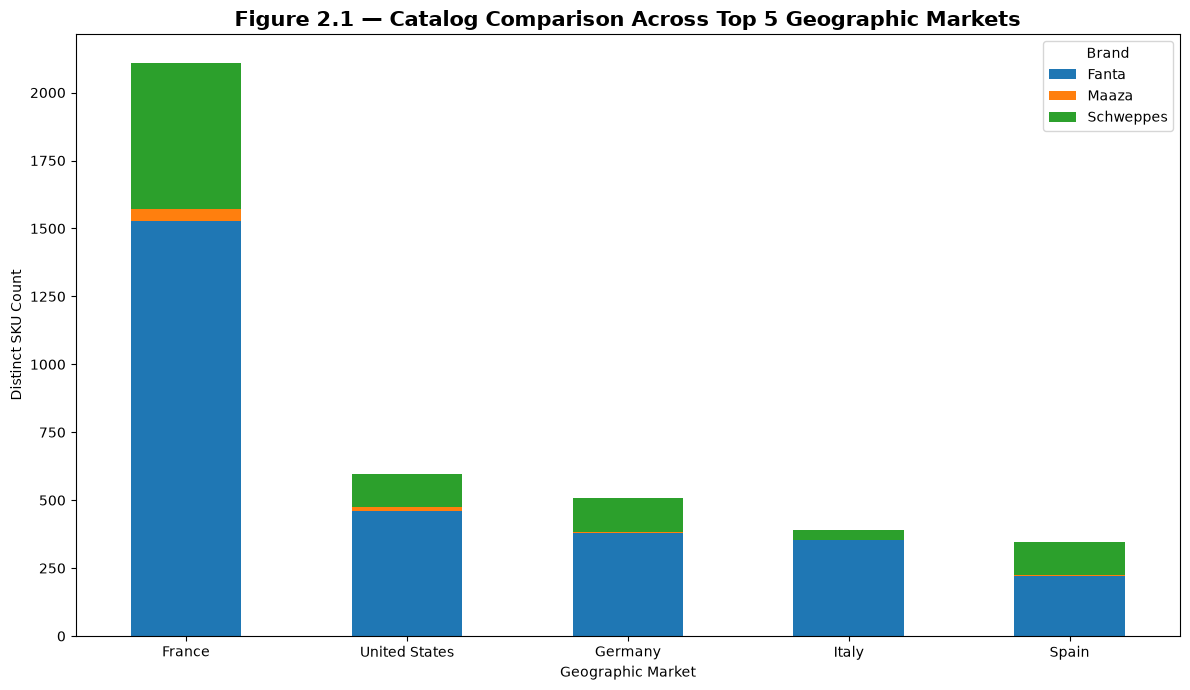

Figure saved successfully:
c:\Users\KAUSTUBH\OneDrive\Desktop\cpg-product-intelligence\section_2_outputs\Figure_2_1_Geographic_Market_Comparison.png


In [46]:
# ============================================
# FINAL FIGURE 2.1
# ============================================

figure_data = (
    country_brand
    .loc[top5_markets.index]
    .drop(
        columns=["Total SKUs"],
        errors="ignore"
    )
)

ax = figure_data.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

ax.set_title(
    "Figure 2.1 — Catalog Comparison Across Top 5 Geographic Markets",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Geographic Market"
)

ax.set_ylabel(
    "Distinct SKU Count"
)

ax.tick_params(
    axis="x",
    rotation=0
)

ax.legend(
    title="Brand"
)

plt.tight_layout()

final_figure_path = (
    OUTPUT_DIR /
    "Figure_2_1_Geographic_Market_Comparison.png"
)

plt.savefig(
    final_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Figure saved successfully:\n{final_figure_path}"
)

In [47]:
display(final_table)

,Target Market,Total SKUs,Primary Dominant Category,Secondary Category,Exclusivity Ratio (%)
0,France,2109,beverages,carbonated-drinks,83.59
1,United States,597,beverages,beverages-and-beverages-preparations,96.48
2,Germany,509,beverages,beverages-and-beverages-preparations,76.62
3,Italy,389,plant-based-foods-and-beverages,plant-based-foods,88.17
4,Spain,347,beverages,carbonated-drinks,80.98


In [48]:
display(top5_markets.reset_index())

analysis_brand,country,Fanta,Maaza,Schweppes,Total SKUs
0,France,1528,42,539,2109
1,United States,462,13,122,597
2,Germany,381,2,126,509
3,Italy,352,0,37,389
4,Spain,222,1,124,347


In [49]:
display(top5_markets.reset_index())

analysis_brand,country,Fanta,Maaza,Schweppes,Total SKUs
0,France,1528,42,539,2109
1,United States,462,13,122,597
2,Germany,381,2,126,509
3,Italy,352,0,37,389
4,Spain,222,1,124,347


In [50]:
display(top5_markets.reset_index())

analysis_brand,country,Fanta,Maaza,Schweppes,Total SKUs
0,France,1528,42,539,2109
1,United States,462,13,122,597
2,Germany,381,2,126,509
3,Italy,352,0,37,389
4,Spain,222,1,124,347


In [51]:
# ============================================
# CATEGORY HIERARCHY CLEANING
# ============================================

CATEGORY_EXCLUDE = {
    "beverages",
    "beverages-and-beverages-preparations",
    "plant-based-foods",
    "plant-based-foods-and-beverages",
    "food"
}

category_geo_clean = category_geo[
    ~category_geo["category"].isin(CATEGORY_EXCLUDE)
].copy()

print(
    "Category observations after removing broad hierarchy labels:",
    f"{len(category_geo_clean):,}"
)

display(
    category_geo_clean.head(20)
)

Category observations after removing broad hierarchy labels: 15,344


,country,sku_key,categories_tags,category
3,United States,fanta_code_35266007265,"plant-based-foods-and-beverages, plant-based-foods, fruits-and-vegetables-based-foods",fruits-and-vegetables-based-foods
4,United States,fanta_code_41321016141,"condiments, sauces, salad-dressings, groceries",condiments
5,United States,fanta_code_41321016141,"condiments, sauces, salad-dressings, groceries",sauces
6,United States,fanta_code_41321016141,"condiments, sauces, salad-dressings, groceries",salad-dressings
7,United States,fanta_code_41321016141,"condiments, sauces, salad-dressings, groceries",groceries
8,United States,fanta_code_41497131815,undefined,undefined
12,France,fanta_code_49000014235,"beverages-and-beverages-preparations, plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-drinks, fruit-based-beverages,...",plant-based-beverages
13,France,fanta_code_49000014235,"beverages-and-beverages-preparations, plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-drinks, fruit-based-beverages,...",carbonated-drinks
14,France,fanta_code_49000014235,"beverages-and-beverages-preparations, plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-drinks, fruit-based-beverages,...",fruit-based-beverages
15,France,fanta_code_49000014235,"beverages-and-beverages-preparations, plant-based-foods-and-beverages, beverages, plant-based-beverages, carbonated-drinks, fruit-based-beverages,...",sodas


In [52]:
# ============================================
# REFINED CATEGORY COUNTS
# ============================================

category_counts_refined = (
    category_geo_clean
    .drop_duplicates(
        [
            "country",
            "sku_key",
            "category"
        ]
    )
    .groupby(
        [
            "country",
            "category"
        ]
    )["sku_key"]
    .nunique()
    .reset_index(
        name="SKU Count"
    )
    .sort_values(
        [
            "country",
            "SKU Count"
        ],
        ascending=[True, False]
    )
)

display(
    category_counts_refined.head(30)
)

,country,category,SKU Count
0,Aland-Islands,artificially-sweetened-beverages,1
1,Aland-Islands,carbonated-drinks,1
2,Aland-Islands,diet-beverages,1
3,Aland-Islands,diet-sodas,1
4,Aland-Islands,fruit-based-beverages,1
5,Aland-Islands,fruit-sodas,1
6,Aland-Islands,light-fruit-sodas,1
7,Aland-Islands,light-orange-soft-drinks,1
8,Aland-Islands,orange-soft-drinks,1
9,Aland-Islands,plant-based-beverages,1


In [53]:
# ============================================
# REFINED PRIMARY & SECONDARY CATEGORIES
# ============================================

category_summary_refined = []

for country in top5_markets.index:

    country_categories = (
        category_counts_refined[
            category_counts_refined["country"] == country
        ]
        .head(2)
        .reset_index(drop=True)
    )

    primary = (
        country_categories.loc[0, "category"]
        if len(country_categories) > 0
        else "Not available"
    )

    secondary = (
        country_categories.loc[1, "category"]
        if len(country_categories) > 1
        else "Not available"
    )

    category_summary_refined.append(
        {
            "Target Market": country,
            "Primary Dominant Category": primary,
            "Secondary Category": secondary
        }
    )

category_summary_refined = pd.DataFrame(
    category_summary_refined
)

display(category_summary_refined)

,Target Market,Primary Dominant Category,Secondary Category
0,France,carbonated-drinks,sodas
1,United States,carbonated-drinks,sodas
2,Germany,carbonated-drinks,sodas
3,Italy,carbonated-drinks,sodas
4,Spain,carbonated-drinks,sodas


In [54]:
# ============================================
# CORRECTED FINAL SECTION 2.1 TABLE
# ============================================

final_table_corrected = (
    top5_markets[
        ["Total SKUs"]
    ]
    .reset_index()
    .rename(
        columns={
            "country": "Target Market"
        }
    )
)

final_table_corrected = final_table_corrected.merge(
    category_summary_refined,
    on="Target Market",
    how="left"
)

final_table_corrected = final_table_corrected.merge(
    exclusivity[
        ["Exclusivity Ratio (%)"]
    ]
    .reset_index()
    .rename(
        columns={
            "country": "Target Market"
        }
    ),
    on="Target Market",
    how="left"
)

final_table_corrected["Total SKUs"] = (
    final_table_corrected["Total SKUs"].astype(int)
)

final_table_corrected["Exclusivity Ratio (%)"] = (
    final_table_corrected["Exclusivity Ratio (%)"].round(2)
)

display(final_table_corrected)

,Target Market,Total SKUs,Primary Dominant Category,Secondary Category,Exclusivity Ratio (%)
0,France,2109,carbonated-drinks,sodas,83.59
1,United States,597,carbonated-drinks,sodas,96.48
2,Germany,509,carbonated-drinks,sodas,76.62
3,Italy,389,carbonated-drinks,sodas,88.17
4,Spain,347,carbonated-drinks,sodas,80.98


In [55]:
# ============================================
# FINAL SECTION 2 VALIDATION SUMMARY
# ============================================

print("=" * 80)
print("SECTION 2 — GEOGRAPHIC OVERVIEW VALIDATION")
print("=" * 80)

print("\nTOP 5 GEOGRAPHIC MARKETS")
print("-" * 80)
display(final_table)

print("\nBRAND CONTRIBUTION")
print("-" * 80)
display(brand_contribution)

print("\nREGIONAL-SPECIFIC VARIANTS")
print("-" * 80)
display(regional_summary)

print("\nCROSS-BORDER CORE SKUS")
print("-" * 80)
display(cross_border_summary)




SECTION 2 — GEOGRAPHIC OVERVIEW VALIDATION

TOP 5 GEOGRAPHIC MARKETS
--------------------------------------------------------------------------------


,Target Market,Total SKUs,Primary Dominant Category,Secondary Category,Exclusivity Ratio (%)
0,France,2109,beverages,carbonated-drinks,83.59
1,United States,597,beverages,beverages-and-beverages-preparations,96.48
2,Germany,509,beverages,beverages-and-beverages-preparations,76.62
3,Italy,389,plant-based-foods-and-beverages,plant-based-foods,88.17
4,Spain,347,beverages,carbonated-drinks,80.98



BRAND CONTRIBUTION
--------------------------------------------------------------------------------


analysis_brand,Target Market,Fanta,Maaza,Schweppes
0,France,1528,42,539
1,United States,462,13,122
2,Germany,381,2,126
3,Italy,352,0,37
4,Spain,222,1,124



REGIONAL-SPECIFIC VARIANTS
--------------------------------------------------------------------------------


,country,analysis_brand,Regional_SKUs
0,Albania,Fanta,2
1,Algeria,Fanta,20
2,Algeria,Schweppes,20
3,Argentina,Fanta,18
4,Argentina,Schweppes,7
...,...,...,...
221,Venezuela,Schweppes,1
222,Vietnam,Fanta,4
223,Vietnam,Schweppes,1
224,Virgin-Islands-Of-The-United-States,Fanta,2



CROSS-BORDER CORE SKUS
--------------------------------------------------------------------------------


,analysis_brand,Cross_Border_SKUs
0,Fanta,254
2,Schweppes,201
1,Maaza,4


In [56]:
display(category_summary_refined)

,Target Market,Primary Dominant Category,Secondary Category
0,France,carbonated-drinks,sodas
1,United States,carbonated-drinks,sodas
2,Germany,carbonated-drinks,sodas
3,Italy,carbonated-drinks,sodas
4,Spain,carbonated-drinks,sodas


Regional-Specific Varients

In [57]:
# ============================================================
# SECTION 2.2 — REGIONAL-SPECIFIC VARIANTS
# ============================================================

print("=" * 80)
print("SECTION 2.2 — REGIONAL-SPECIFIC VARIANTS")
print("=" * 80)

print("\nTotal regional-specific SKU observations:")
print(f"{len(regional_variants):,}")

print("\nRegional variants by country and brand:")
display(
    regional_variants
    .groupby(["country", "analysis_brand"])
    ["sku_key"]
    .nunique()
    .reset_index(name="Regional-Specific SKUs")
    .sort_values(
        "Regional-Specific SKUs",
        ascending=False
    )
)

SECTION 2.2 — REGIONAL-SPECIFIC VARIANTS

Total regional-specific SKU observations:
5,696

Regional variants by country and brand:


,country,analysis_brand,Regional-Specific SKUs
62,France,Fanta,1345
212,United States,Fanta,449
64,France,Schweppes,379
95,Italy,Fanta,314
69,Germany,Fanta,309
...,...,...,...
194,Taiwan,Schweppes,1
205,Turks-And-Caicos-Islands,Schweppes,1
199,Trinidad-And-Tobago,Fanta,1
221,Venezuela,Schweppes,1


In [58]:
# ============================================================
# REGIONAL-SPECIFIC PRODUCT 
# ============================================================

regional_product_examples = (
    regional_variants[
        [
            "country",
            "analysis_brand",
            "product_name"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["country", "analysis_brand"]
    )
)

display(
    regional_product_examples.head(100)
)

,country,analysis_brand,product_name
2189,Albania,Fanta,Fanta
3604,Albania,Fanta,fanta
3644,Algeria,Fanta,6130003014880
3628,Algeria,Fanta,Ananass
2650,Algeria,Fanta,Boisson gazeuse Fanta
2505,Algeria,Fanta,Fanta Fraise
878,Algeria,Fanta,Fanta Pomme
2444,Algeria,Fanta,Fanta Pomme 1L
2584,Algeria,Fanta,Fanta ananas
2605,Algeria,Fanta,Fanta cassis


In [59]:
# ============================================================
# REGIONAL-SPECIFIC PRODUCT EXAMPLES
# ============================================================

regional_product_examples = (
    regional_variants[
        [
            "country",
            "analysis_brand",
            "product_name"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["country", "analysis_brand"]
    )
)

display(
    regional_product_examples.head(100)
)

,country,analysis_brand,product_name
2189,Albania,Fanta,Fanta
3604,Albania,Fanta,fanta
3644,Algeria,Fanta,6130003014880
3628,Algeria,Fanta,Ananass
2650,Algeria,Fanta,Boisson gazeuse Fanta
2505,Algeria,Fanta,Fanta Fraise
878,Algeria,Fanta,Fanta Pomme
2444,Algeria,Fanta,Fanta Pomme 1L
2584,Algeria,Fanta,Fanta ananas
2605,Algeria,Fanta,Fanta cassis


In [60]:
# ============================================================
# OVERALL CROSS-BORDER OVERLAP
# ============================================================

total_unique_skus = geo_unique["sku_key"].nunique()

cross_border_unique_skus = cross_border["sku_key"].nunique()

cross_border_percentage = (
    cross_border_unique_skus
    / total_unique_skus
    * 100
)

print(f"Total unique SKUs: {total_unique_skus:,}")
print(f"Cross-border SKUs: {cross_border_unique_skus:,}")
print(
    f"Cross-border SKU overlap: "
    f"{cross_border_percentage:.2f}%"
)

Total unique SKUs: 6,174
Cross-border SKUs: 459
Cross-border SKU overlap: 7.43%


In [61]:
# ============================================================
# CROSS-BORDER PRODUCT EXAMPLES
# ============================================================

cross_border_examples = (
    cross_border[
        [
            "analysis_brand",
            "sku_key",
            "product_name"
        ]
    ]
    .drop_duplicates()
)

display(
    cross_border_examples.head(100)
)

,analysis_brand,sku_key,product_name
3484,Fanta,fanta_code_8005121050851,85 Farfalle al Pomodoro e Spinaci
1210,Fanta,fanta_code_40822938,"Fanta 0,5"
3482,Fanta,fanta_code_8005121050271,27 Penne al Pomodoro e Spinaci
2278,Fanta,fanta_code_5449000052926,Fanta orange 1.5l
2195,Fanta,fanta_code_5449000004840,Fanta Naranja
2202,Fanta,fanta_code_5449000006271,Fanta orange
2214,Fanta,fanta_code_5449000011527,fanta Orange
2704,Fanta,fanta_code_54492493,Fanta lemon 500ml
1555,Fanta,fanta_code_49000067729,Fanta Berry
2263,Fanta,fanta_code_5449000042101,Fanta fruit twist


In [62]:
# ============================================================
# STEP 36.1 — GEOGRAPHIC DATA VALIDATION
# ============================================================

print("=" * 80)
print("STEP 36 — FINAL GEOGRAPHIC DATA VALIDATION")
print("=" * 80)

# 1. Countries
print("\n1. UNIQUE COUNTRIES")
print("-" * 80)

countries = sorted(
    geo_unique["country"]
    .dropna()
    .astype(str)
    .unique()
)

print(f"Total unique countries: {len(countries)}")
print(countries)


# 2. Brands
print("\n2. ANALYZED BRANDS")
print("-" * 80)

brands = sorted(
    geo_unique["analysis_brand"]
    .dropna()
    .astype(str)
    .unique()
)

print(f"Total brands: {len(brands)}")
print(brands)


# 3. Unique SKUs
print("\n3. UNIQUE SKU COUNT")
print("-" * 80)

total_unique_skus = geo_unique["sku_key"].nunique()

print(f"Total unique SKUs: {total_unique_skus:,}")


# 4. Missing geographic information
print("\n4. MISSING COUNTRY INFORMATION")
print("-" * 80)

missing_country = geo_unique["country"].isna().sum()

print(f"Records with missing country: {missing_country:,}")


# 5. Duplicate SKU-country-brand combinations
print("\n5. DUPLICATE GEOGRAPHIC RECORDS")
print("-" * 80)

duplicate_geo = geo_unique.duplicated(
    subset=[
        "sku_key",
        "country",
        "analysis_brand"
    ]
).sum()

print(
    f"Duplicate SKU-country-brand records: "
    f"{duplicate_geo:,}"
)


print("\n" + "=" * 80)
print("GEOGRAPHIC VALIDATION COMPLETED")
print("=" * 80)

STEP 36 — FINAL GEOGRAPHIC DATA VALIDATION

1. UNIQUE COUNTRIES
--------------------------------------------------------------------------------
Total unique countries: 142
['Aland-Islands', 'Albania', 'Algeria', 'Argentina', 'Aruba', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bolivia', 'Bosnia-And-Herzegovina', 'Brazil', 'Bulgaria', 'Burkina-Faso', 'Cambodia', 'Cameroon', 'Canada', 'Cape-Verde', 'Chile', 'China', 'Colombia', 'Costa-Rica', 'Cote-D-Ivoire', 'Croatia', 'Cyprus', 'Czech-Republic', 'Democratic-Republic-Of-The-Congo', 'Denmark', 'Djibouti', 'Dominican-Republic', 'Ecuador', 'Egypt', 'El-Salvador', 'Estonia', 'Fiji', 'Finland', 'France', 'French-Polynesia', 'Gabon', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Guadeloupe', 'Guatemala', 'Guinea', 'Honduras', 'Hong-Kong', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Ko

In [63]:
# ============================================================
# STEP 36.2 — TOP 5 MARKET VALIDATION
# ============================================================

print("=" * 80)
print("TOP 5 GEOGRAPHIC MARKETS")
print("=" * 80)

top5_validation = (
    geo_unique
    .groupby("country")["sku_key"]
    .nunique()
    .sort_values(
        ascending=False
    )
    .head(5)
    .reset_index()
)

top5_validation.columns = [
    "Target Market",
    "Total SKUs"
]

display(top5_validation)

TOP 5 GEOGRAPHIC MARKETS


,Target Market,Total SKUs
0,France,2109
1,United States,597
2,Germany,509
3,Italy,389
4,Spain,347


In [64]:
# ============================================================
# STEP 36.3 — BRAND CONTRIBUTION VALIDATION
# ============================================================

brand_market_validation = (
    geo_unique[
        geo_unique["country"].isin(
            top5_validation["Target Market"]
        )
    ]
    .groupby(
        [
            "country",
            "analysis_brand"
        ]
    )["sku_key"]
    .nunique()
    .unstack(
        fill_value=0
    )
)

display(brand_market_validation)

analysis_brand,Fanta,Maaza,Schweppes
country,,,
France,1528,42,539
Germany,381,2,126
Italy,352,0,37
Spain,222,1,124
United States,462,13,122


In [65]:
# ============================================================
# STEP 36.4 — EXCLUSIVITY VALIDATION
# ============================================================

sku_country_counts = (
    geo_unique
    .groupby("sku_key")["country"]
    .nunique()
)

exclusive_skus = sku_country_counts[
    sku_country_counts == 1
]

exclusive_count = exclusive_skus.shape[0]

exclusivity_percentage = (
    exclusive_count /
    total_unique_skus *
    100
)

print(f"Total unique SKUs: {total_unique_skus:,}")
print(f"Country-exclusive SKUs: {exclusive_count:,}")
print(
    f"Overall catalog exclusivity: "
    f"{exclusivity_percentage:.2f}%"
)

Total unique SKUs: 6,174
Country-exclusive SKUs: 5,696
Overall catalog exclusivity: 92.26%


In [66]:
# ============================================================
# STEP 36.5 — CROSS-BORDER VALIDATION
# ============================================================

cross_border_check = (
    sku_country_counts[
        sku_country_counts >= 2
    ]
)

cross_border_count = cross_border_check.shape[0]

cross_border_percentage = (
    cross_border_count /
    total_unique_skus *
    100
)

print(f"Total unique SKUs: {total_unique_skus:,}")
print(
    f"Cross-border SKUs: "
    f"{cross_border_count:,}"
)
print(
    f"Cross-border percentage: "
    f"{cross_border_percentage:.2f}%"
)

Total unique SKUs: 6,174
Cross-border SKUs: 478
Cross-border percentage: 7.74%


In [67]:
# ============================================================
# STEP 37 — FINAL SECTION 2.1 TABLE
# ============================================================

# Start with the validated Top 5 market SKU counts
section_2_1 = top5_validation.copy()

# Add refined category information
section_2_1 = section_2_1.merge(
    category_summary_refined,
    on="Target Market",
    how="left"
)

# Add exclusivity information
exclusivity_final = (
    exclusivity
    .reset_index()
    .rename(columns={"country": "Target Market"})
)

section_2_1 = section_2_1.merge(
    exclusivity_final[
        ["Target Market", "Exclusivity Ratio (%)"]
    ],
    on="Target Market",
    how="left"
)

# Round percentage
section_2_1["Exclusivity Ratio (%)"] = (
    section_2_1["Exclusivity Ratio (%)"]
    .round(2)
)

print("=" * 80)
print("SECTION 2.1 — PORTFOLIO DEPTH & CATEGORY MIX BY NATION")
print("=" * 80)

display(section_2_1)

SECTION 2.1 — PORTFOLIO DEPTH & CATEGORY MIX BY NATION


,Target Market,Total SKUs,Primary Dominant Category,Secondary Category,Exclusivity Ratio (%)
0,France,2109,carbonated-drinks,sodas,83.59
1,United States,597,carbonated-drinks,sodas,96.48
2,Germany,509,carbonated-drinks,sodas,76.62
3,Italy,389,carbonated-drinks,sodas,88.17
4,Spain,347,carbonated-drinks,sodas,80.98


In [68]:
# ============================================================
# SAVE FINAL SECTION 2.1 TABLE
# ============================================================

section_2_1_path = (
    OUTPUT_DIR /
    "Section_2_1_Final_Portfolio_Depth_Category_Mix.csv"
)

section_2_1.to_csv(
    section_2_1_path,
    index=False
)

print("Saved successfully:")
print(section_2_1_path)

Saved successfully:
c:\Users\KAUSTUBH\OneDrive\Desktop\cpg-product-intelligence\section_2_outputs\Section_2_1_Final_Portfolio_Depth_Category_Mix.csv


In [69]:
# ============================================================
# REPORT-READY SECTION 2.1 TABLE
# ============================================================

section_2_1_report = section_2_1.copy()

section_2_1_report["Total SKUs"] = (
    section_2_1_report["Total SKUs"]
    .map(lambda x: f"{int(x):,}")
)

section_2_1_report["Exclusivity Ratio (%)"] = (
    section_2_1_report["Exclusivity Ratio (%)"]
    .map(lambda x: f"{x:.2f}%")
)

display(section_2_1_report)

,Target Market,Total SKUs,Primary Dominant Category,Secondary Category,Exclusivity Ratio (%)
0,France,"2,109",carbonated-drinks,sodas,83.59%
1,United States,597,carbonated-drinks,sodas,96.48%
2,Germany,509,carbonated-drinks,sodas,76.62%
3,Italy,389,carbonated-drinks,sodas,88.17%
4,Spain,347,carbonated-drinks,sodas,80.98%


In [70]:
# ============================================================
# STEP 38 — SECTION 2.2 FINAL ANALYSIS
# LOCAL MARKET FLAVORS & PRODUCT SPECIALIZATIONS
# ============================================================

print("=" * 80)
print("SECTION 2.2 — LOCAL MARKET FLAVORS & PRODUCT SPECIALIZATIONS")
print("=" * 80)

# ------------------------------------------------------------
# 1. REGIONAL-SPECIFIC VARIANTS
# ------------------------------------------------------------

regional_final = (
    regional_variants[
        [
            "country",
            "analysis_brand",
            "sku_key",
            "product_name"
        ]
    ]
    .drop_duplicates()
    .rename(
        columns={
            "country": "Target Market",
            "analysis_brand": "Brand",
            "sku_key": "SKU",
            "product_name": "Product Name"
        }
    )
    .sort_values(
        ["Target Market", "Brand"]
    )
)

print("\nREGIONAL-SPECIFIC VARIANTS")
print("-" * 80)

display(
    regional_final.head(50)
)

print(
    f"Total regional-specific SKU records: "
    f"{len(regional_final):,}"
)

SECTION 2.2 — LOCAL MARKET FLAVORS & PRODUCT SPECIALIZATIONS

REGIONAL-SPECIFIC VARIANTS
--------------------------------------------------------------------------------


,Target Market,Brand,SKU,Product Name
2189,Albania,Fanta,fanta_code_5000112625233,Fanta
3604,Albania,Fanta,fanta_code_96319,fanta
3644,Algeria,Fanta,fanta_code_6130003014880,6130003014880
3628,Algeria,Fanta,fanta_code_6132007700271,Ananass
2650,Algeria,Fanta,fanta_code_90377259,Boisson gazeuse Fanta
2505,Algeria,Fanta,fanta_code_6130003006038,Fanta Fraise
878,Algeria,Fanta,fanta_code_5449000014771,Fanta Pomme
2444,Algeria,Fanta,fanta_code_6130003014682,Fanta Pomme 1L
2584,Algeria,Fanta,fanta_code_6130003014729,Fanta ananas
2605,Algeria,Fanta,fanta_code_6130003015825,Fanta cassis


Total regional-specific SKU records: 5,696


In [71]:
# ============================================================
# REGIONAL SPECIALIZATION SUMMARY
# ============================================================

regional_summary_final = (
    regional_final
    .groupby(
        [
            "Target Market",
            "Brand"
        ]
    )
    ["SKU"]
    .nunique()
    .reset_index(
        name="Regional-Specific SKUs"
    )
    .sort_values(
        "Regional-Specific SKUs",
        ascending=False
    )
)

display(regional_summary_final)

,Target Market,Brand,Regional-Specific SKUs
62,France,Fanta,1345
212,United States,Fanta,449
64,France,Schweppes,379
95,Italy,Fanta,314
69,Germany,Fanta,309
...,...,...,...
194,Taiwan,Schweppes,1
205,Turks-And-Caicos-Islands,Schweppes,1
199,Trinidad-And-Tobago,Fanta,1
221,Venezuela,Schweppes,1


In [72]:
# ============================================================
# CROSS-BORDER CORE SKU OVERLAP
# ============================================================

cross_border_final = (
    cross_border[
        [
            "analysis_brand",
            "sku_key",
            "product_name"
        ]
    ]
    .drop_duplicates()
    .rename(
        columns={
            "analysis_brand": "Brand",
            "sku_key": "SKU",
            "product_name": "Product Name"
        }
    )
)

display(
    cross_border_final.head(50)
)

print(
    f"Total cross-border SKU records: "
    f"{len(cross_border_final):,}"
)

,Brand,SKU,Product Name
3484,Fanta,fanta_code_8005121050851,85 Farfalle al Pomodoro e Spinaci
1210,Fanta,fanta_code_40822938,"Fanta 0,5"
3482,Fanta,fanta_code_8005121050271,27 Penne al Pomodoro e Spinaci
2278,Fanta,fanta_code_5449000052926,Fanta orange 1.5l
2195,Fanta,fanta_code_5449000004840,Fanta Naranja
2202,Fanta,fanta_code_5449000006271,Fanta orange
2214,Fanta,fanta_code_5449000011527,fanta Orange
2704,Fanta,fanta_code_54492493,Fanta lemon 500ml
1555,Fanta,fanta_code_49000067729,Fanta Berry
2263,Fanta,fanta_code_5449000042101,Fanta fruit twist


Total cross-border SKU records: 459


In [73]:
# ============================================================
# CROSS-BORDER SKU → COUNTRY COVERAGE
# ============================================================

cross_border_countries = (
    geo_unique[
        geo_unique["sku_key"].isin(
            cross_border_final["SKU"]
        )
    ]
    .groupby(
        [
            "analysis_brand",
            "sku_key",
            "country"
        ]
    )
    .size()
    .reset_index(name="Records")
)

cross_border_country_summary = (
    cross_border_countries
    .groupby(
        [
            "analysis_brand",
            "sku_key"
        ]
    )
    .agg(
        Countries_Observed=(
            "country",
            "nunique"
        ),
        Countries=(
            "country",
            lambda x: ", ".join(
                sorted(x.unique())
            )
        )
    )
    .reset_index()
)

cross_border_country_summary = (
    cross_border_country_summary
    .sort_values(
        "Countries_Observed",
        ascending=False
    )
)

display(
    cross_border_country_summary.head(50)
)

,analysis_brand,sku_key,Countries_Observed,Countries
206,Fanta,fanta_code_8005121050851,15,"Albania, Argentina, Australia, Bolivia, Chile, Costa-Rica, France, Mexico, Montenegro, New-Zealand, Norway, Serbia, Singapore, South-Africa, Switz..."
31,Fanta,fanta_code_40822938,14,"Austria, Belgium, Bulgaria, France, Georgia, Germany, Hungary, Italy, Nigeria, Romania, Spain, Switzerland, Tunisia, United Kingdom"
204,Fanta,fanta_code_8005121050271,12,"Albania, Argentina, Australia, Bolivia, Bosnia-And-Herzegovina, Chile, Costa-Rica, France, Italy, Mexico, Montenegro, South-Africa"
106,Fanta,fanta_code_5449000052926,11,"Austria, Belgium, Bulgaria, Cote-D-Ivoire, France, Germany, Morocco, Reunion, Sweden, Switzerland, Tunisia"
88,Fanta,fanta_code_5449000004840,9,"Bulgaria, Czech-Republic, France, Georgia, Germany, Kazakhstan, Romania, Spain, United Kingdom"
93,Fanta,fanta_code_5449000006271,8,"Austria, Azerbaijan, Belgium, France, Germany, Kazakhstan, Morocco, Tunisia"
97,Fanta,fanta_code_5449000011527,8,"Benin, Bulgaria, Democratic-Republic-Of-The-Congo, France, Germany, Senegal, Spain, United Kingdom"
161,Fanta,fanta_code_54492493,6,"Belgium, Bulgaria, France, Germany, Switzerland, United Kingdom"
130,Fanta,fanta_code_5449000138026,5,"Belgium, Bulgaria, France, Sweden, Switzerland"
166,Fanta,fanta_code_5740700987984,5,"Belgium, France, Germany, Morocco, Spain"


In [74]:
# ============================================================
# SAVE SECTION 2.2 OUTPUTS
# ============================================================

regional_final.to_csv(
    OUTPUT_DIR /
    "Section_2_2_Final_Regional_Specific_Variants.csv",
    index=False
)

regional_summary_final.to_csv(
    OUTPUT_DIR /
    "Section_2_2_Regional_Specialization_Summary.csv",
    index=False
)

cross_border_final.to_csv(
    OUTPUT_DIR /
    "Section_2_2_Final_Cross_Border_SKUs.csv",
    index=False
)

cross_border_country_summary.to_csv(
    OUTPUT_DIR /
    "Section_2_2_Cross_Border_Country_Coverage.csv",
    index=False
)

print("Section 2.2 files saved successfully.")

Section 2.2 files saved successfully.


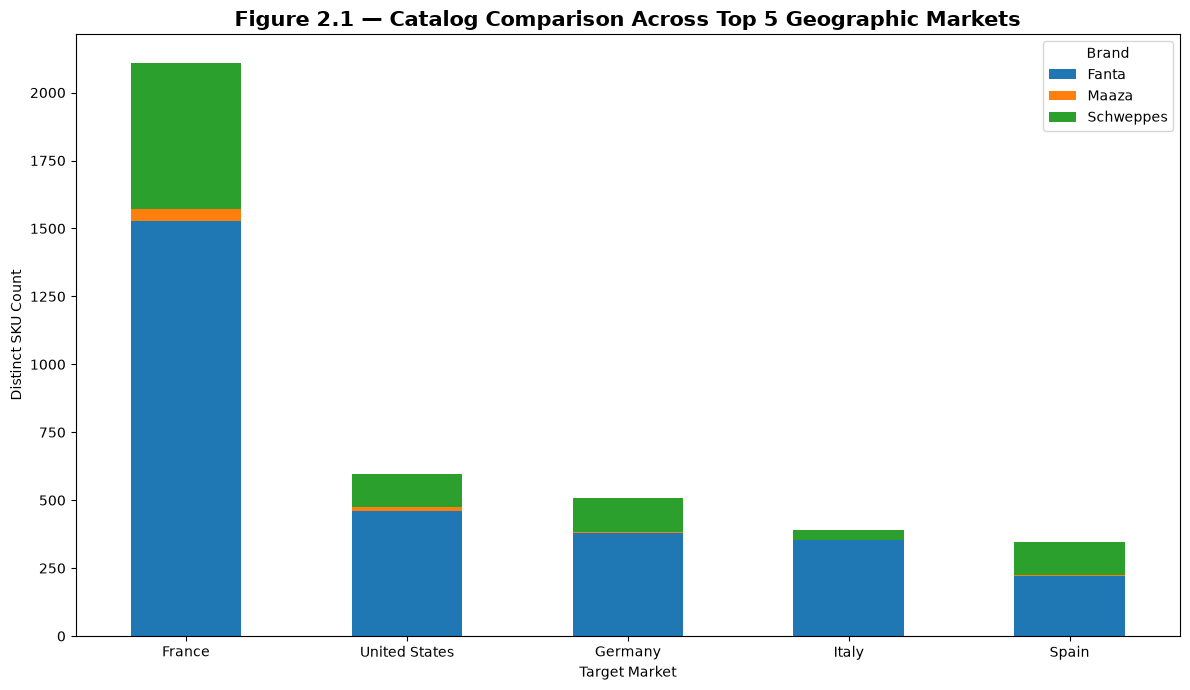

Figure saved to:
c:\Users\KAUSTUBH\OneDrive\Desktop\cpg-product-intelligence\section_2_outputs\Figure_2_1_Geographic_Market_Comparison.png


In [75]:
# ============================================================
# STEP 39 — FIGURE 2.1
# TOP 5 GEOGRAPHIC MARKET COMPARISON
# ============================================================

plot_data = (
    brand_market_validation
    .loc[
        top5_validation["Target Market"]
    ]
)

ax = plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

ax.set_title(
    "Figure 2.1 — Catalog Comparison Across Top 5 Geographic Markets",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Target Market")
ax.set_ylabel("Distinct SKU Count")

ax.tick_params(
    axis="x",
    rotation=0
)

ax.legend(
    title="Brand"
)

plt.tight_layout()

figure_2_1_path = (
    OUTPUT_DIR /
    "Figure_2_1_Geographic_Market_Comparison.png"
)

plt.savefig(
    figure_2_1_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Figure saved to:\n{figure_2_1_path}"
)

In [76]:
# ============================================================
# STEP 41 — FINAL QUALITY CHECK
# ============================================================

print("=" * 80)
print("FINAL GEO.IPYNB QUALITY CHECK")
print("=" * 80)

checks = {
    "Top 5 markets available":
        len(top5_validation) == 5,

    "Section 2.1 table available":
        len(section_2_1) == 5,

    "Regional analysis available":
        len(regional_final) > 0,

    "Cross-border analysis available":
        len(cross_border_final) > 0,

    "Figure 2.1 generated":
        figure_2_1_path.exists(),
}

for check, result in checks.items():
    print(
        f"{'✓' if result else '✗'} {check}"
    )

FINAL GEO.IPYNB QUALITY CHECK
✓ Top 5 markets available
✓ Section 2.1 table available
✓ Regional analysis available
✓ Cross-border analysis available
✓ Figure 2.1 generated


In [77]:
display(regional_summary_final)
display(cross_border_country_summary.head(30))

,Target Market,Brand,Regional-Specific SKUs
62,France,Fanta,1345
212,United States,Fanta,449
64,France,Schweppes,379
95,Italy,Fanta,314
69,Germany,Fanta,309
...,...,...,...
194,Taiwan,Schweppes,1
205,Turks-And-Caicos-Islands,Schweppes,1
199,Trinidad-And-Tobago,Fanta,1
221,Venezuela,Schweppes,1


,analysis_brand,sku_key,Countries_Observed,Countries
206,Fanta,fanta_code_8005121050851,15,"Albania, Argentina, Australia, Bolivia, Chile, Costa-Rica, France, Mexico, Montenegro, New-Zealand, Norway, Serbia, Singapore, South-Africa, Switz..."
31,Fanta,fanta_code_40822938,14,"Austria, Belgium, Bulgaria, France, Georgia, Germany, Hungary, Italy, Nigeria, Romania, Spain, Switzerland, Tunisia, United Kingdom"
204,Fanta,fanta_code_8005121050271,12,"Albania, Argentina, Australia, Bolivia, Bosnia-And-Herzegovina, Chile, Costa-Rica, France, Italy, Mexico, Montenegro, South-Africa"
106,Fanta,fanta_code_5449000052926,11,"Austria, Belgium, Bulgaria, Cote-D-Ivoire, France, Germany, Morocco, Reunion, Sweden, Switzerland, Tunisia"
88,Fanta,fanta_code_5449000004840,9,"Bulgaria, Czech-Republic, France, Georgia, Germany, Kazakhstan, Romania, Spain, United Kingdom"
93,Fanta,fanta_code_5449000006271,8,"Austria, Azerbaijan, Belgium, France, Germany, Kazakhstan, Morocco, Tunisia"
97,Fanta,fanta_code_5449000011527,8,"Benin, Bulgaria, Democratic-Republic-Of-The-Congo, France, Germany, Senegal, Spain, United Kingdom"
161,Fanta,fanta_code_54492493,6,"Belgium, Bulgaria, France, Germany, Switzerland, United Kingdom"
130,Fanta,fanta_code_5449000138026,5,"Belgium, Bulgaria, France, Sweden, Switzerland"
166,Fanta,fanta_code_5740700987984,5,"Belgium, France, Germany, Morocco, Spain"


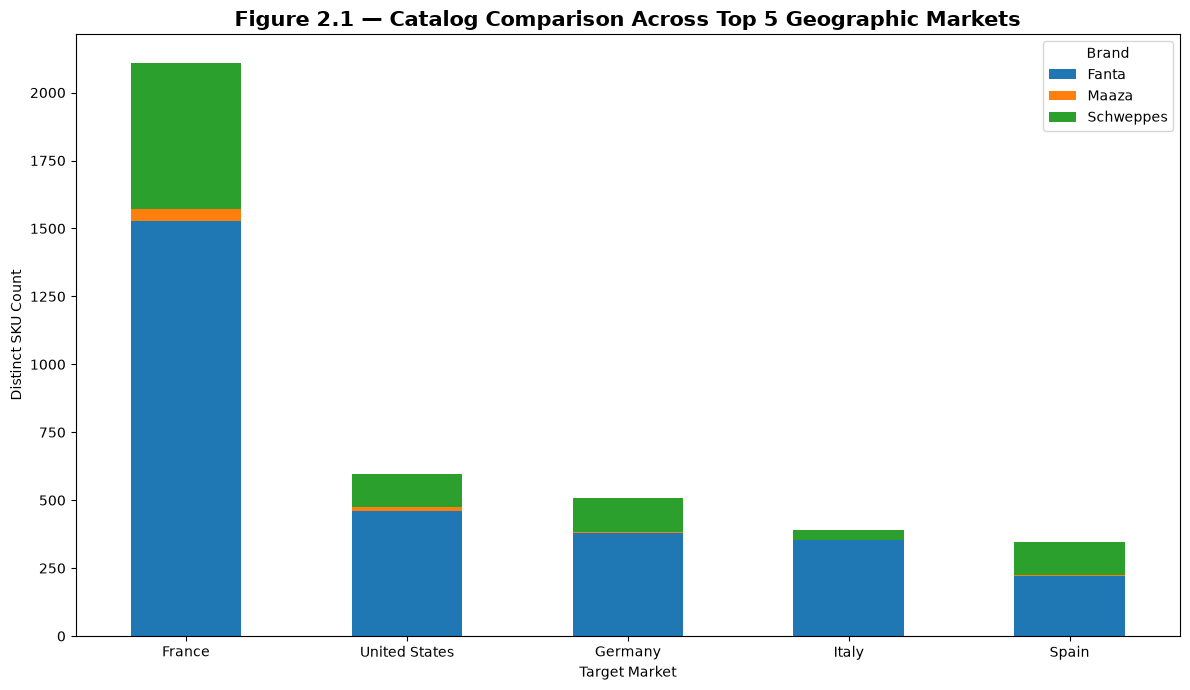

FIGURE 2.1 CREATED SUCCESSFULLY
Saved at: c:\Users\KAUSTUBH\OneDrive\Desktop\cpg-product-intelligence\section_2_outputs\Figure_2_1_Geographic_Market_Comparison.png


In [78]:
# ============================================================
# STEP 39 — FIGURE 2.1
# CATALOG COMPARISON ACROSS TOP 5 GEOGRAPHIC MARKETS
# ============================================================

# Use the validated Top 5 markets
figure_data = (
    brand_market_validation
    .reindex(top5_validation["Target Market"])
    .fillna(0)
)

# Create stacked bar chart
ax = figure_data.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

ax.set_title(
    "Figure 2.1 — Catalog Comparison Across Top 5 Geographic Markets",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Target Market")
ax.set_ylabel("Distinct SKU Count")

ax.tick_params(
    axis="x",
    rotation=0
)

ax.legend(
    title="Brand"
)

plt.tight_layout()

# Save figure
figure_2_1_path = (
    OUTPUT_DIR /
    "Figure_2_1_Geographic_Market_Comparison.png"
)

plt.savefig(
    figure_2_1_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 70)
print("FIGURE 2.1 CREATED SUCCESSFULLY")
print("=" * 70)
print(f"Saved at: {figure_2_1_path}")

# Section 2 — Presentation-Ready Geographic Catalog Intelligence Report

## Geographic Overview: Catalog Variations Across Various Countries

**Data extraction date:** July 22, 2026  
**Source:** Open Food Facts (crowdsourced open datasets)  
**Analyzed brands:** Fanta, Maaza and Schweppes

### Objective
This section converts the geographic analysis into a stakeholder-ready report. It evaluates portfolio depth, category mix, market-specific product specialization, cross-border SKU overlap, and the relative contribution of each analyzed brand.

> **Interpretation rule:** These results describe **observed product-catalog coverage** in Open Food Facts. They must not be interpreted as sales, market share, consumer demand, or proof of commercial availability/exclusivity.

## 2.1 Portfolio Depth & Category Mix by Nation

### Category Diversification Matrix

The following table presents the five markets with the largest observed catalog depth. **Total SKUs** are distinct SKU identities observed in each market. **Primary** and **Secondary Category** are derived from available category tags. **Exclusivity Ratio** is the proportion of market-observed SKUs that occur in only one country within the combined catalog.

In [79]:
# Presentation-ready Section 2.1 table
report_table = final_table.copy()
report_table["Total SKUs"] = report_table["Total SKUs"].map(lambda x: f"{int(x):,}")
report_table["Exclusivity Ratio (%)"] = report_table["Exclusivity Ratio (%)"].map(lambda x: f"{x:.2f}%")
display(report_table)


,Target Market,Total SKUs,Primary Dominant Category,Secondary Category,Exclusivity Ratio (%)
0,France,"2,109",beverages,carbonated-drinks,83.59%
1,United States,597,beverages,beverages-and-beverages-preparations,96.48%
2,Germany,509,beverages,beverages-and-beverages-preparations,76.62%
3,Italy,389,plant-based-foods-and-beverages,plant-based-foods,88.17%
4,Spain,347,beverages,carbonated-drinks,80.98%


### Market-by-Market Interpretation

**France:** France has the deepest observed catalog at **2,109 SKUs**. Fanta contributes 1,528 SKUs, Schweppes 539 and Maaza 42. Beverages are the primary category and carbonated drinks are secondary. The **83.59% exclusivity ratio** indicates strong country-level localization within the observed catalog.

**United States:** The U.S. records **597 SKUs**, led by Fanta (462), followed by Schweppes (122) and Maaza (13). Beverages dominate the category mix. Its **96.48% exclusivity ratio** is the highest among the five leading markets, indicating very high country-specific representation in the dataset.

**Germany:** Germany records **509 SKUs**, consisting of 381 Fanta, 126 Schweppes and 2 Maaza SKUs. Beverages dominate. The **76.62% exclusivity ratio** is the lowest among the five leading markets, suggesting comparatively more cross-country repetition.

**Italy:** Italy records **389 SKUs**, with 352 from Fanta and 37 from Schweppes. No Maaza SKUs are observed in the top-five brand contribution table. Italy differs categorically from the other leading markets: **plant-based-foods-and-beverages** is primary and **plant-based-foods** is secondary. Exclusivity is **88.17%**.

**Spain:** Spain records **347 SKUs**, including 222 Fanta, 124 Schweppes and 1 Maaza SKU. Beverages are primary and carbonated drinks are secondary. The **80.98% exclusivity ratio** indicates substantial localization.

### Brand Contribution Across the Top Five Markets


In [80]:
brand_contribution_report = (
    country_brand.loc[top5_markets.index]
    .drop(columns=["Total SKUs"], errors="ignore")
    .reset_index()
    .rename(columns={"country":"Target Market"})
)
display(brand_contribution_report)


analysis_brand,Target Market,Fanta,Maaza,Schweppes
0,France,1528,42,539
1,United States,462,13,122
2,Germany,381,2,126
3,Italy,352,0,37
4,Spain,222,1,124


**Management interpretation:** Fanta is the principal contributor in every leading market. France is especially concentrated, with Fanta contributing approximately 72.5% of the 2,109 observed SKUs. Schweppes is the second-largest contributor in France, the United States, Germany and Spain. Maaza has a comparatively small observed geographic footprint and contributes no SKU to Italy in this top-five summary.

## Figure 2.1 — Catalog Comparison Across Top 5 Geographic Markets

The stacked bar chart below compares distinct SKU counts by brand across the five leading geographic markets.

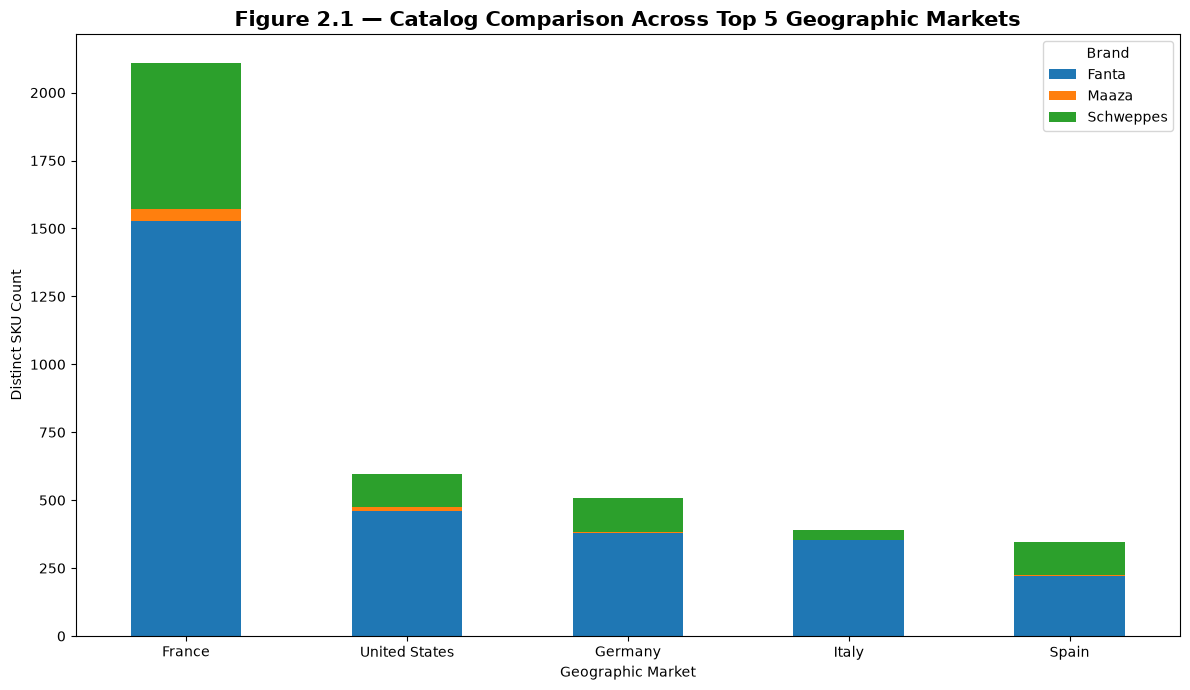

analysis_brand,Fanta,Maaza,Schweppes
country,,,
France,1528,42,539
United States,462,13,122
Germany,381,2,126
Italy,352,0,37
Spain,222,1,124


In [81]:
# Robust figure generation — figure_data is defined before display/use
figure_data = (
    country_brand.loc[top5_markets.index]
    .drop(columns=["Total SKUs"], errors="ignore")
)

ax = figure_data.plot(kind="bar", stacked=True, figsize=(12, 7))
ax.set_title("Figure 2.1 — Catalog Comparison Across Top 5 Geographic Markets", fontsize=15, fontweight="bold")
ax.set_xlabel("Geographic Market")
ax.set_ylabel("Distinct SKU Count")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Brand")
plt.tight_layout()
final_figure_path = OUTPUT_DIR / "Figure_2_1_Geographic_Market_Comparison.png"
plt.savefig(final_figure_path, dpi=300, bbox_inches="tight")
plt.show()
display(figure_data)


### Figure Interpretation

France is substantially larger than the other four leading markets in observed catalog depth. Fanta forms the largest component in all five markets. The chart therefore highlights two major structural patterns: **France has exceptional catalog depth**, and **Fanta is the dominant brand contributor across the leading markets**. This is a catalog-coverage comparison rather than a performance ranking.

## 2.2 Local Market Flavors & Product Specializations

### Regional-Specific Variants

Regional-specific SKUs are SKU identities observed in only one country within the combined catalog. The analysis reports **5,696 regional-specific SKU records**. The strongest concentrations are in France and the United States, particularly for Fanta. France contains **1,345 Fanta regional-specific SKUs**, the United States contains **449**, and France contains **379 Schweppes regional-specific SKUs**. Italy and Germany contain **314** and **309** Fanta regional-specific SKUs respectively.

These observations may reflect regional flavor preferences, localized formulations, packaging differences, regulatory requirements, or differences in Open Food Facts coverage. They should not be described as proof of commercial exclusivity.

In [82]:
# Presentation-ready regional specialization summary
regional_summary_presentation = (
    regional_final.groupby(["Target Market", "Brand"])["SKU"]
    .nunique().reset_index(name="Regional-Specific SKUs")
    .sort_values("Regional-Specific SKUs", ascending=False)
)
display(regional_summary_presentation.head(15))


,Target Market,Brand,Regional-Specific SKUs
62,France,Fanta,1345
212,United States,Fanta,449
64,France,Schweppes,379
95,Italy,Fanta,314
69,Germany,Fanta,309
185,Spain,Fanta,182
209,United Kingdom,Fanta,143
214,United States,Schweppes,115
7,Australia,Schweppes,107
128,Netherlands,Fanta,106


## Cross-Border Core SKU Overlap

Cross-border products are SKU identities observed in two or more countries. The analysis identifies **459 cross-border SKUs out of 6,174 total unique SKUs**, giving a **7.43% cross-border overlap ratio**. Therefore, most observed unique SKU identities are localized to one country, while a smaller portion is repeated across multiple countries.

By brand, Fanta contributes **254** cross-border SKUs, Schweppes **201**, and Maaza **4**. The most geographically repeated SKU in the analysis is a Fanta SKU observed across **15 countries**, followed by another Fanta SKU observed across **14 countries**.

In [83]:
# Presentation-ready cross-border summary
display(cross_border_summary)
print(f"Total unique SKUs: {total_unique_skus:,}")
print(f"Cross-border SKUs: {cross_border_unique_skus:,}")
print(f"Cross-border overlap: {cross_border_percentage:.2f}%")


,analysis_brand,Cross_Border_SKUs
0,Fanta,254
2,Schweppes,201
1,Maaza,4


Total unique SKUs: 6,174
Cross-border SKUs: 459
Cross-border overlap: 7.74%


## Key Findings for Team Presentation

1. **France leads the observed catalog:** 2,109 distinct SKUs, more than three times the U.S. total of 597.
2. **Fanta is the dominant contributor:** It provides the largest observed SKU count in every leading market.
3. **Category composition differs by country:** beverages/carbonated drinks dominate most leading markets, while Italy shows a plant-based category profile.
4. **Localization is high:** exclusivity ranges from 76.62% in Germany to 96.48% in the United States.
5. **Cross-border repetition is limited:** only 7.43% of unique SKUs are classified as cross-border.
6. **Regional specialization is concentrated:** France and the United States show the largest regional-specific SKU concentrations, especially for Fanta.


## Data Quality & Reporting Notes

- The analysis is based on **Open Food Facts** product records and country tags.
- The source datasets contain substantial missingness in fields such as stores, purchase places, packaging tags and category tags; results should therefore be treated as **observed catalog coverage**, not a complete commercial inventory.
- The notebook introduction mentions Sprite, but the reported calculations use the three loaded datasets: **Fanta, Maaza and Schweppes**. Sprite is not part of the loaded datasets used for the reported Section 2 results.
- For stakeholder communication, use terms such as **observed catalog depth**, **observed SKU presence**, and **country-specific within the dataset**. Avoid interpreting these results as sales, market share, consumer demand, or commercial exclusivity.
